# CarbonLens
# UIC CS 418, Fall 2025 Final Project
**Authors: Karthik Kesavarapu, Shri Chatrati, Shounak Sawant, Rahee Chauhan**

## Project Introduction:

As there is an increasing concern about the prevalent issues that are starting to arise with global warming, consumers are starting to become more aware of the products that release more carbon emmissions. However, some applications may not include specific carbon data, and if they do consumers are not sure if it is the appropriate and eco-friendly which ultimately leaves buyers unaware of the true environmental cost of their choices. CarbonLens aims to solve this problem by predicting the CO2 emissions of appliances using machine learning, based on publicly available features such as energy usage, materials, and origin. 

The purpose of this application is to hypothesize whether or not a product's CO2 emissions can be accurately estimated with quantitative and qualitative being predicted. In other words, we propose that machine learnning can estimate the carbon footprint of appliances based on standard specification data, which will increase customer awareness of environmental impact. 

## Project Changes Since Proposal:
One of the major changes since the project proposal was the scope of the data. Our plan originally had a CO2 emmissions dataset and a database. We are choosing as a group to get rid of these two datasets as it confuses of what the scope of the project actually is. The very first dataset that we have just talks about the carbon emmissions over time which alraedy has a data visualization in the website. Furthermore, it is common knowledge, we also assume that our audience knows this, that the industrial revolution in 1960 caused a rise of CO2 emmissions. Instead of these two datasets, we are opting to choose a dataset from energystar.gov which is a US private company that keeps track of emmissions of different appliances. This also solidifies the scope of the project as now our project will examine the CO2 Emissions in the United Staes of America. 

## Energy Star Certified Product Data Sets
Within this dataset, there are so many different appliances that are grouped by different categories. We have decided to pick categories that people are expected to use almost daily which includes appliances, heating and cooling, electronics and home office, lighting and fans, and vehicle charging. Althoguh this may seem like a bias for appliances that will emmit a lot more carbon dioxide because it is used more, it falls under the scope of the project because we are trying to find out the patterns of CO2 emmissions from daily used products. From these different appliances, we used a simple random sample (SRS) so that all of the appliances have an equal opportunity of being picked. 

The appliances that we are going to use are:
1. Refrigerators
2. Room Air Conditioners
3. Televisions
4. Ceiling Fans
5. Ovens

This is a good stratification of 5 different types of appliances that will show the overall trends of CO2 usage in daily appliances

## Imports for this project:

In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import date, datetime
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.inspection import permutation_importance
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from collections import Counter
import seaborn as sns


## Part I: Data Preparation
In this section, we are going to prepare the data from the source.

### Obtaining and Cleaning Refrigerator Data

In [137]:
dfRefrigerator = pd.read_csv('Residential Refrigerators.csv')
# Display the first few rows of the dataframe
print(dfRefrigerator.head())
print(dfRefrigerator.columns.tolist())

   ENERGY STAR Unique ID Brand Name    Model Number  \
0                4015668        ABL        AREF18**   
1                4015667        ABL         AREF18B   
2                4015665        ABL         AREF18S   
3                4015666        ABL         AREF18W   
4                2403036   Absocold  ARD1033FB21R/L   

  Additional Model Information  UPC         Type  \
0                          NaN  NaN  Top Freezer   
1                          NaN  NaN  Top Freezer   
2                          NaN  NaN  Top Freezer   
3                          NaN  NaN  Top Freezer   
4                          NaN  NaN  Top Freezer   

                                       Product Class Defrost Type Compact  \
0  3 - Refrigerator-freezers - automatic defrost ...    Automatic      No   
1  3 - Refrigerator-freezers - automatic defrost ...    Automatic      No   
2  3 - Refrigerator-freezers - automatic defrost ...    Automatic      No   
3  3 - Refrigerator-freezers - automatic defrost

This is a lot of columns with a lot of data information. Let's try cleaning it up!

In [138]:
# 1. Drop duplicates
dfRefrigerator = dfRefrigerator.drop_duplicates()

# 2. Remove completely empty columns
dfRefrigerator = dfRefrigerator.dropna(axis=1, how='all')

# 3. Remove rows missing key values
dfRefrigerator = dfRefrigerator.dropna(subset=["Brand Name", "Model Number", "Annual Energy Use (kWh/yr)", "Additional Model Information"])

# 4. Convert numeric columns to proper types
numeric_cols = [
    "Annual Energy Use (kWh/yr)",
    "US Federal Standard (kWh/yr)",
    "Percent Less Energy Use than US Federal Standard",
    "Height (in)",
    "Width (in)",
    "Capacity (Total Volume) (ft3)"
]
dfRefrigerator[numeric_cols] = dfRefrigerator[numeric_cols].apply(pd.to_numeric, errors="coerce")

# 5. Drop rows with invalid or 0 energy values
dfRefrigerator = dfRefrigerator[dfRefrigerator["Annual Energy Use (kWh/yr)"] > 0]

# 6. Standardize brand names
dfRefrigerator["Brand Name"] = dfRefrigerator["Brand Name"].str.strip().str.title()

# 7. Convert all Yes/No columns to 1/0
for col in dfRefrigerator.columns:
    if dfRefrigerator[col].isin(['Yes', 'No']).any():
        dfRefrigerator[col] = dfRefrigerator[col].replace({'Yes': 1, 'No': 0})


# 8. Reset index
dfRefrigerator = dfRefrigerator.reset_index(drop=True)

# 9. Convert date columns to proper datetime objects
date_cols = ["Date Available On Market", "Date Certified"]
for col in date_cols:
    dfRefrigerator[col] = pd.to_datetime(dfRefrigerator[col], format="%m/%d/%Y", errors="coerce")

# 10. Preview cleaned data
print(dfRefrigerator.info())
print(dfRefrigerator.head())

# 11. Save Cleaned File
dfRefrigerator.to_csv("Refrigerators_Cleaned.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 604 entries, 0 to 603
Data columns (total 32 columns):
 #   Column                                                  Non-Null Count  Dtype         
---  ------                                                  --------------  -----         
 0   ENERGY STAR Unique ID                                   604 non-null    int64         
 1   Brand Name                                              604 non-null    object        
 2   Model Number                                            604 non-null    object        
 3   Additional Model Information                            604 non-null    object        
 4   UPC                                                     375 non-null    object        
 5   Type                                                    602 non-null    object        
 6   Product Class                                           604 non-null    object        
 7   Defrost Type                                            593 no

/var/folders/qx/7x4_nq3x477cy8z6b9jjdqkw0000gn/T/ipykernel_83376/1355213630.py:30: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dfRefrigerator[col] = dfRefrigerator[col].replace({'Yes': 1, 'No': 0})


The process for the remaining datasets are similar. Let's clean all of the remaining data!

### Obtaining and Cleaning the Air Conditioner Data

In [139]:
dfAirConditioner = pd.read_csv('Room Air Conditioners.csv')
# Display the first few rows of the dataframe
print(dfAirConditioner.head())
print(dfAirConditioner.columns.tolist())

   ENERGY STAR Unique ID    Brand Name Model Number  \
0                3387785  BLACK+DECKER     BD08NWES   
1                3387786  BLACK+DECKER     BD10NWES   
2                3387787  BLACK+DECKER     BD12NWES   
3                3629713       Century    RXTS-101A   
4                3629714       Century    RXTS-121A   

  Additional Model Information           UPC  Height (inches)  Width (inches)  \
0                          NaN  810064695360             13.5            18.6   
1                          NaN  810064695377             13.5            18.6   
2                          NaN  810064695384             14.6            19.1   
3                          NaN           NaN             13.5            19.2   
4                          NaN           NaN             13.5            19.2   

   Depth (inches)  Weight (lbs) Cooling Capacity (Btu/hr)  ...  \
0            19.6          44.1                     8,000  ...   
1            19.6          46.1                   

In [140]:
# 1. Drop duplicates
dfAC = dfAirConditioner.drop_duplicates()

# 2. Remove fully empty columns
dfAC = dfAC.dropna(axis=1, how='all')

# 3. Clean Cooling Capacity (remove commas, convert)
dfAC["Cooling Capacity (Btu/hr)"] = (
    dfAC["Cooling Capacity (Btu/hr)"]
    .astype(str)
    .str.replace(",", "", regex=True)
)

dfAC["Cooling Capacity (Btu/hr)"] = pd.to_numeric(
    dfAC["Cooling Capacity (Btu/hr)"], errors="coerce"
)

# 4. Convert other numeric columns
num_cols = [
    "Annual Energy Use (kWh/yr)",
    "Voltage (volts)",
    "Percent Less Energy Use than US Federal Standard",
    "Combined Energy Efficiency Ratio (CEER)"
]

for col in num_cols:
    dfAC[col] = pd.to_numeric(dfAC[col], errors="coerce")


# 5. Drop rows missing essential information
dfAC = dfAC.dropna(subset=[
    "Brand Name",
    "Model Number",
    "Cooling Capacity (Btu/hr)",
    "Annual Energy Use (kWh/yr)"
])


# 6. Standardize brand names
dfAC["Brand Name"] = dfAC["Brand Name"].str.strip().str.title()


# 7. Convert yes/no → 1/0
for col in dfAC.columns:
    if dfAC[col].isin(["Yes", "No"]).any():
        dfAC[col] = dfAC[col].replace({"Yes": 1, "No": 0})


# 8. Convert date columns
for col in ["Date Available On Market", "Date Certified"]:
    dfAC[col] = pd.to_datetime(dfAC[col], errors="coerce")


# 9. Reset index

dfAC = dfAC.reset_index(drop=True)


# 10. Save cleaned file
dfAC.to_csv("AirConditioners_Cleaned.csv", index=False)

print(dfAC.info())
print(dfAC.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 28 columns):
 #   Column                                            Non-Null Count  Dtype         
---  ------                                            --------------  -----         
 0   ENERGY STAR Unique ID                             255 non-null    int64         
 1   Brand Name                                        255 non-null    object        
 2   Model Number                                      255 non-null    object        
 3   Additional Model Information                      14 non-null     object        
 4   UPC                                               195 non-null    object        
 5   Height (inches)                                   255 non-null    float64       
 6   Width (inches)                                    255 non-null    float64       
 7   Depth (inches)                                    255 non-null    float64       
 8   Weight (lbs)                  

/var/folders/qx/7x4_nq3x477cy8z6b9jjdqkw0000gn/T/ipykernel_83376/1916119807.py:46: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dfAC[col] = dfAC[col].replace({"Yes": 1, "No": 0})


### Obtaining and Cleaning the Television Data

In [141]:
dfTelevisionData = pd.read_csv('Televisions.csv')
# Display the first few rows of the dataframe
print(dfTelevisionData.head())
print(dfTelevisionData.columns.tolist())

   ENERGY STAR Unique ID                                ENERGY STAR Partner  \
0                2402123                          Curtis International Ltd.   
1                2403227  ELITELUX TECHNOLOGIES,INC./GLOBAL Q. INTERNATI...   
2                3554271  ELITELUX TECHNOLOGIES,INC./GLOBAL Q. INTERNATI...   
3                2399940  ELITELUX TECHNOLOGIES,INC./GLOBAL Q. INTERNATI...   
4                3554326  ELITELUX TECHNOLOGIES,INC./GLOBAL Q. INTERNATI...   

  Brand Name Model Name Model Number  \
0        RCA       65D1         65D1   
1     Sansui    LE-24T1      LE-24T1   
2     Sansui   LE-24TA1     LE-24TA1   
3     Sansui    LE-32T1      LE-32T1   
4     Sansui    LE-32V1      LE-32V1   

                        Additional Model Information  UPC     Product Type  \
0  ,65N1,; ,RTAU6504,; ,RTAU6540.,; ,RTRU6527,; ,...  NaN  Television (TV)   
1  ,EC24T1H,; ,EC24T1HA,; ,EC24T1HN,; ,EC24T2H,; ...  NaN  Television (TV)   
2  ,****24****.,; ,C24V1HW,; ,C24VAHW,; ,LE-24T1,.

In [142]:
# 1. Drop duplicates
dfTelevisionData = dfTelevisionData.drop_duplicates()

# 2. Drop fully empty columns
dfTelevisionData = dfTelevisionData.dropna(axis=1, how='all')

# 3. Drop rows missing essential identifiers
dfTelevisionData = dfTelevisionData.dropna(subset=["Brand Name", "Model Number", "Reported Annual Energy Consumption (kWh)"])

# 4. Clean numeric columns
numeric_cols = [
    "Reported Annual Energy Consumption (kWh)",
    "Average On Mode Power Consumption for Certification (watts)",
    "Maximum Average On Mode Power for Certification (watts)",
    "Reported On Mode Power (per the Federal Test Procedure) (watts)",
    "Measured Standby Mode Power (Watts)",
    "Power Consumption in Standby Mode when Not Connected to a Network (watts)",
    "Power Consumption in Standby Mode when Connected to a Network (watts)",
    "Reported Standby-Active, Low Mode Power (watts)",
    "Diagonal Viewable Screen Size (in.)",
    "Screen Area (sq. in.)",
    "Native Horizontal Resolution (pixels)",
    "Native Vertical Resolution (pixels)"
]

for col in numeric_cols:
    if col in dfTelevisionData.columns:
        if dfTelevisionData[col].dtype == object:
            dfTelevisionData[col] = dfTelevisionData[col].str.replace(',', '', regex=True)
        dfTelevisionData[col] = pd.to_numeric(dfTelevisionData[col], errors="coerce")

# 5. Remove rows with invalid or zero energy consumption
dfTelevisionData = dfTelevisionData[dfTelevisionData["Reported Annual Energy Consumption (kWh)"] > 0]

# 6. Normalize brand names
dfTelevisionData["Brand Name"] = dfTelevisionData["Brand Name"].str.strip().str.title()

# 7. Convert Yes/No to 1/0
for col in dfTelevisionData.columns:
    if dfTelevisionData[col].isin(['Yes', 'No']).any():
        dfTelevisionData[col] = dfTelevisionData[col].replace({'Yes': 1, 'No': 0})

# 8. Convert date columns to datetime
date_cols = ["Date Available On Market", "Date Certified"]
for col in date_cols:
    dfTelevisionData[col] = pd.to_datetime(dfTelevisionData[col], format="%m/%d/%Y", errors="coerce")

# 9. Reset index
dfTelevisionData = dfTelevisionData.reset_index(drop=True)

# 10. Preview cleaned data
print(dfTelevisionData.info())
print(dfTelevisionData.head())

# 11. Save Cleaned File
dfTelevisionData.to_csv("Televisions_Cleaned.csv", index=False)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146 entries, 0 to 145
Data columns (total 35 columns):
 #   Column                                                                                                                    Non-Null Count  Dtype         
---  ------                                                                                                                    --------------  -----         
 0   ENERGY STAR Unique ID                                                                                                     146 non-null    int64         
 1   ENERGY STAR Partner                                                                                                       146 non-null    object        
 2   Brand Name                                                                                                                146 non-null    object        
 3   Model Name                                                                                          

/var/folders/qx/7x4_nq3x477cy8z6b9jjdqkw0000gn/T/ipykernel_83376/807767605.py:41: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dfTelevisionData[col] = dfTelevisionData[col].replace({'Yes': 1, 'No': 0})


### Obtaining and Cleaning Data the Ceiling Fans Data

In [143]:
dfCeilingFans = pd.read_csv('Ceiling Fans.csv')
# Display the first few rows of the dataframe
print(dfCeilingFans.head())
print(dfCeilingFans.columns.tolist())

   ENERGY STAR Unique ID ENERGY STAR Partner Brand Name   Model Name  \
0                2386171    Aeratron Pty Ltd   AERATRON  Ceiling Fan   
1                2385543    Aeratron Pty Ltd   AERATRON  Ceiling Fan   
2                2386170    Aeratron Pty Ltd   AERATRON  Ceiling Fan   
3                2385542    Aeratron Pty Ltd   AERATRON  Ceiling Fan   
4                2386169    Aeratron Pty Ltd   AERATRON  Ceiling Fan   

   Model Number              Additional Model Information  \
0   AE+2WI43***  ,,Each * to represent a letter or blank.   
1  AE+2WI43L***  ,,Each * to represent a letter or blank.   
2   AE+2WI50***  ,,Each * to represent a letter or blank.   
3  AE+2WI50L***  ,,Each * to represent a letter or blank.   
4   AE+2WI60***  ,,Each * to represent a letter or blank.   

                                                 UPC      Indoor/Outdoor  \
0  850021862015;850021862022;850021862039;8500218...  Indoor Ceiling Fan   
1  850021862015;850021862022;850021862039;850021

In [144]:
# 1. Clean column names (remove hidden spaces)
dfCeilingFans.columns = dfCeilingFans.columns.str.strip()

# 2. Drop duplicates
dfCeilingFans = dfCeilingFans.drop_duplicates()

# 3. Drop fully empty columns
dfCeilingFans = dfCeilingFans.dropna(axis=1, how='all')

# 4. Remove rows missing key info
dfCeilingFans = dfCeilingFans.dropna(subset=["Brand Name", "Model Number", "Ceiling Fan Efficiency (CFM/W)"])

# 5. Convert numeric columns
numeric_cols = [
    "Blade Span (Diameter) (in.)",
    "Ceiling Fan Efficiency (CFM/W)",
    "Fan Power Consumption-Low Speed (W)",
    "Fan Power Consumption-High Speed (W)",
    "Fan Power Consumption-Standby (W)",
    "Ceiling Fan Components Warranty (Years)",
    "Total Light Output (lumens)",
    "Total Lighting Input Power (Watts)",
    "Lighting Efficiency – Measured outside the Fixture (lm/W)",
    "Lighting Efficiency – Measured at the Source (lm/W)",
    "Power Factor of Light Kit",
    "Light Color Appearance (CCT)",
    "Light Color Quality (CRI)",
    "Light Source Rated Life (Hours)",
    "Light Sources Per Light Kit",
    "Ceiling Fan Light Kit Warranty (yrs)"
]

for col in numeric_cols:
    if col in dfCeilingFans.columns:
        if dfCeilingFans[col].dtype == object:
            dfCeilingFans[col] = dfCeilingFans[col].str.replace(',', '', regex=True)
        dfCeilingFans[col] = pd.to_numeric(dfCeilingFans[col], errors="coerce")

# 6. Drop rows with invalid or zero efficiency
dfCeilingFans = dfCeilingFans[dfCeilingFans["Ceiling Fan Efficiency (CFM/W)"] > 0]

# 7. Normalize brand names
dfCeilingFans["Brand Name"] = dfCeilingFans["Brand Name"].str.strip().str.title()

# 8. Convert Yes/No columns to 1/0
for col in dfCeilingFans.columns:
    if dfCeilingFans[col].isin(['Yes', 'No']).any():
        dfCeilingFans[col] = dfCeilingFans[col].replace({'Yes': 1, 'No': 0})

# 9. Convert dates to datetime
from datetime import datetime
date_cols = ["Date Available on Market", "Date Certified"]
for col in date_cols:
    if col in dfCeilingFans.columns:
        dfCeilingFans[col] = pd.to_datetime(dfCeilingFans[col], format="%m/%d/%Y", errors="coerce")

# 10. Reset index
dfCeilingFans = dfCeilingFans.reset_index(drop=True)

# 11. Preview cleaned data
print(dfCeilingFans.info())
print(dfCeilingFans.head())

# 12. Save Cleaned File
dfCeilingFans.to_csv("CeilingFans_Cleaned.csv", index=False)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1144 entries, 0 to 1143
Data columns (total 32 columns):
 #   Column                                          Non-Null Count  Dtype         
---  ------                                          --------------  -----         
 0   ENERGY STAR Unique ID                           1144 non-null   int64         
 1   ENERGY STAR Partner                             1144 non-null   object        
 2   Brand Name                                      1144 non-null   object        
 3   Model Name                                      1144 non-null   object        
 4   Model Number                                    1144 non-null   object        
 5   Additional Model Information                    542 non-null    object        
 6   UPC                                             642 non-null    object        
 7   Indoor/Outdoor                                  1144 non-null   object        
 8   Product Type                                    

/var/folders/qx/7x4_nq3x477cy8z6b9jjdqkw0000gn/T/ipykernel_83376/3209051774.py:48: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dfCeilingFans[col] = dfCeilingFans[col].replace({'Yes': 1, 'No': 0})


### Obtaining and Cleaning Data the Ovens Data

In [145]:
dfOvens = pd.read_csv('Ovens.csv')
# Display the first few rows of the dataframe
print(dfOvens.head())
print(dfOvens.columns.tolist())

   ENERGY STAR Unique ID ENERGY STAR Partner                    Brand Name  \
0                3942789    Alto-Shaam, Inc.                    Alto-Shaam   
1                3722150    Alto-Shaam, Inc.  Alto-Shaam - Prodigi Classic   
2                3722082    Alto-Shaam, Inc.  Alto-Shaam - Prodigi Classic   
3                2407803    Alto-Shaam, Inc.  Alto-Shaam - Prodigi Classic   
4                2407802    Alto-Shaam, Inc.      Alto-Shaam - Prodigi Pro   

  Model Name Model Number Additional Model Information  UPC Product Type  \
0  CTP10-20G    CTP10-20G                          NaN  NaN  Combination   
1  CTC20-10G    CTC20-10G                          NaN  NaN  Combination   
2  CTC20-20E    CTC20-20E                          NaN  NaN  Combination   
3  CTP20-20G    CTP20-20G                          NaN  NaN  Combination   
4  CTC20-20G    CTC20-20G                          NaN  NaN  Combination   

                                 Oven Classification       Size  ...  \
0 

In [146]:
# 1) Drop dups / empty cols
dfOvens = dfOvens.drop_duplicates()
dfOvens = dfOvens.dropna(axis=1, how='all')

# 2) Drop rows missing core identifiers
core_cols = ["Brand Name", "Model Number", "Product Type"]
present_core = [c for c in core_cols if c in dfOvens.columns]
if present_core:
    dfOvens = dfOvens.dropna(subset=present_core)

# 3) Numeric conversions (only if column exists)
numeric_cols = [
    "Input Rate (kW)",
    "Input Rate (Btu/hr)",
    "Gas Oven Convection Mode Pre-Heat Energy (Btu)",
    "Electric Oven Convection Mode Pre-Heat Energy (kWh)",
    "Convection Mode Pre-Heat Time (min)",
    "Gas Oven Steam Mode Pre-Heat Energy (Btu)",
    "Electric Oven Steam Mode Pre-Heat Energy (kWh)",
    "Steam Mode Pre-Heat Time (min)",
    "Electric Oven Convection Mode Idle Energy Rate (kW)",
    "Gas Oven Convection Mode Idle Energy Rate (Btu/hr)",
    "Gas Oven Convection Mode Electric Idle Energy Rate (kW)",
    "Gas Oven Convection Mode Total Idle Energy Rate (Btu/hr)",
    "Half-Size and Full-Size Steam Pan Capacity",
    "Two-Thirds-Size Steam Pan Capacity",
    "Half-Size Sheet Pan Capacity",
    "Full-Size Sheet Pan Capacity",
    "Electric Oven Steam Mode Idle Energy Rate (kW)",
    "Gas Oven Steam Mode Idle Energy Rate (Btu/hr)",
    "Gas Oven Steam Mode Electric Idle Energy Rate (kW)",
    "Gas Oven Steam Mode Total Idle Energy Rate (Btu/hr)",
    "Convection Mode Cooking Energy Efficiency (%)",
    "Steam Mode Cooking Energy Efficiency (%)",
    "Convection Mode Production Capacity (lbs/hr)",
    "Steam Mode Production Capacity (lbs/hr)",
    "Convection Mode Cooking Period Water Consumption (gal/pan)",
    "Convection Mode Idle Period Water Consumption (gal/hr/pan)",
    "Steam Mode Cooking Period Water Consumption (gal/pan)",
    "Steam Mode Idle Period Water Consumption (gal/hr/pan)",
    "Rack Oven Baking-Energy Efficiency (%)",
    "Baking Production Capacity (lbs/hr)",
    "Steam Injection Period Water Consumption (gal/min)"
]

for col in numeric_cols:
    if col in dfOvens.columns:
        # strip and remove commas
        dfOvens[col] = (
            dfOvens[col]
            .astype(str)
            .str.strip()
            .str.replace(",", "", regex=True)
            .replace({"": None})
        )
        dfOvens[col] = pd.to_numeric(dfOvens[col], errors="coerce")

# 4) Normalize brand names
if "Brand Name" in dfOvens.columns:
    dfOvens["Brand Name"] = dfOvens["Brand Name"].astype(str).str.strip().str.title()

# 5) Yes/No -> 1/0
for col in dfOvens.columns:
    if dfOvens[col].isin(["Yes", "No"]).any():
        dfOvens[col] = dfOvens[col].replace({"Yes": 1, "No": 0})

# 6) Date parsing
for dcol in ["Date Available on Market", "Date Certified"]:
    if dcol in dfOvens.columns:
        dfOvens[dcol] = pd.to_datetime(dfOvens[dcol], format="%m/%d/%Y", errors="coerce")

# 7) Sanity bounds (efficiency % between 0 and 100)
for ecol in ["Convection Mode Cooking Energy Efficiency (%)",
             "Steam Mode Cooking Energy Efficiency (%)",
             "Rack Oven Baking-Energy Efficiency (%)"]:
    if ecol in dfOvens.columns:
        dfOvens.loc[(dfOvens[ecol] < 0) | (dfOvens[ecol] > 100), ecol] = pd.NA

# 8) Reset index and preview
dfOvens = dfOvens.reset_index(drop=True)
print(dfOvens.info())
print(dfOvens.head())

# 9) Save Cleaned File
dfOvens.to_csv("Ovens_Cleaned.csv", index=False)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 331 entries, 0 to 330
Data columns (total 48 columns):
 #   Column                                                      Non-Null Count  Dtype         
---  ------                                                      --------------  -----         
 0   ENERGY STAR Unique ID                                       331 non-null    int64         
 1   ENERGY STAR Partner                                         331 non-null    object        
 2   Brand Name                                                  331 non-null    object        
 3   Model Name                                                  331 non-null    object        
 4   Model Number                                                331 non-null    object        
 5   Additional Model Information                                104 non-null    object        
 6   UPC                                                         11 non-null     object        
 7   Product Type              

/var/folders/qx/7x4_nq3x477cy8z6b9jjdqkw0000gn/T/ipykernel_83376/3473025587.py:65: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dfOvens[col] = dfOvens[col].replace({"Yes": 1, "No": 0})


## How did we prepare the data?

There were 5 csv files that we decided to use using the SRS methods from the different stratified categories. For each of these 5 csv files, we dropped duplicate values, got rid of empty columsn, dropped rows missing essential identifiers, cleaned up numeric columns, gave certain attention to percentages and float values, converted Yes/No to 1/0, and finally converted date columns to datetime objects. These are all essential clean up and preparation for the data so that when we analyze it we do not get some weird distribution or our data will not be influenced by any abhorrent outliers. We then saved this data into seperate CSV files that are cleaned and are going to use these cleaned dataset for the rest of the project. 

## Part II: Exploratory Data Analysis

### Author: Shri Chatrati

In this section, we are going to examine how the datasets look like from a broader perspective and see interesting trends that we can analyze at a much more detailed level. 

### Let's begin by exploring the Refrigerators Data

       ENERGY STAR Unique ID     Compact    Built-in  Thru the Door Dispenser  \
count           6.040000e+02  604.000000  604.000000               604.000000   
mean            3.027203e+06    0.379139    0.105960                 0.067881   
std             7.889532e+05    0.485575    0.308042                 0.251750   
min             2.212651e+06    0.000000    0.000000                 0.000000   
25%             2.379256e+06    0.000000    0.000000                 0.000000   
50%             2.470812e+06    0.000000    0.000000                 0.000000   
75%             3.798604e+06    1.000000    0.000000                 0.000000   
max             4.512365e+06    1.000000    1.000000                 1.000000   

        Ice Maker  Counter Depth  Height (in)  Width (in)  \
count  604.000000     604.000000   604.000000  604.000000   
mean     0.301325       0.135762    54.597682   26.558775   
std      0.459214       0.342819    21.201721    6.890612   
min      0.000000       0.

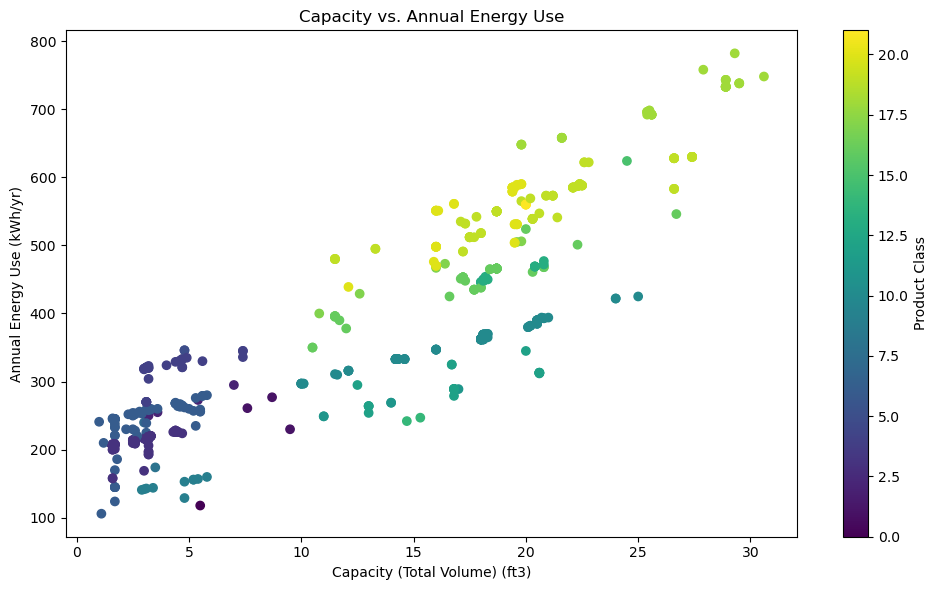

In [147]:
# Load the cleaned Residential Refrigerators dataset
df_refrigerators = pd.read_csv('Refrigerators_Cleaned.csv')


# Display basic statistics
print(df_refrigerators.describe())


# Confirming missing values = 0
missing_values = df_refrigerators.isnull().sum()
print("Missing values per column:\n", missing_values)


# Visualization: Scatter plot of Capacity vs. Annual Energy Use
plt.figure(figsize=(10, 6))
plt.scatter(df_refrigerators["Capacity (Total Volume) (ft3)"], df_refrigerators["Annual Energy Use (kWh/yr)"], c=df_refrigerators["Product Class"].astype('category').cat.codes, cmap="viridis")
plt.title("Capacity vs. Annual Energy Use")
plt.xlabel("Capacity (Total Volume) (ft3)")
plt.ylabel("Annual Energy Use (kWh/yr)")
plt.colorbar(label="Product Class")
plt.tight_layout()
plt.show()


#### Observations from the Refrigerator Data

- **Positive Trend:** Larger refrigerators use more energy, which makes sense since they have more space to cool.  

- **Clusters:** Product classes form clear groups, showing differences in efficiency and design. 
 
- **Outliers:** Some smaller fridges use more power than expected, while a few big ones are surprisingly efficient.


### Exploring the Room Air Conditioners Data

   ENERGY STAR Unique ID    Brand Name Model Number  \
0                3387785  Black+Decker     BD08NWES   
1                3387786  Black+Decker     BD10NWES   
2                3387787  Black+Decker     BD12NWES   
3                3629713       Century    RXTS-101A   
4                3629714       Century    RXTS-121A   

  Additional Model Information           UPC  Height (inches)  Width (inches)  \
0                          NaN  810064695360             13.5            18.6   
1                          NaN  810064695377             13.5            18.6   
2                          NaN  810064695384             14.6            19.1   
3                          NaN           NaN             13.5            19.2   
4                          NaN           NaN             13.5            19.2   

   Depth (inches)  Weight (lbs)  Cooling Capacity (Btu/hr)  ...  \
0            19.6          44.1                       8000  ...   
1            19.6          46.1                 

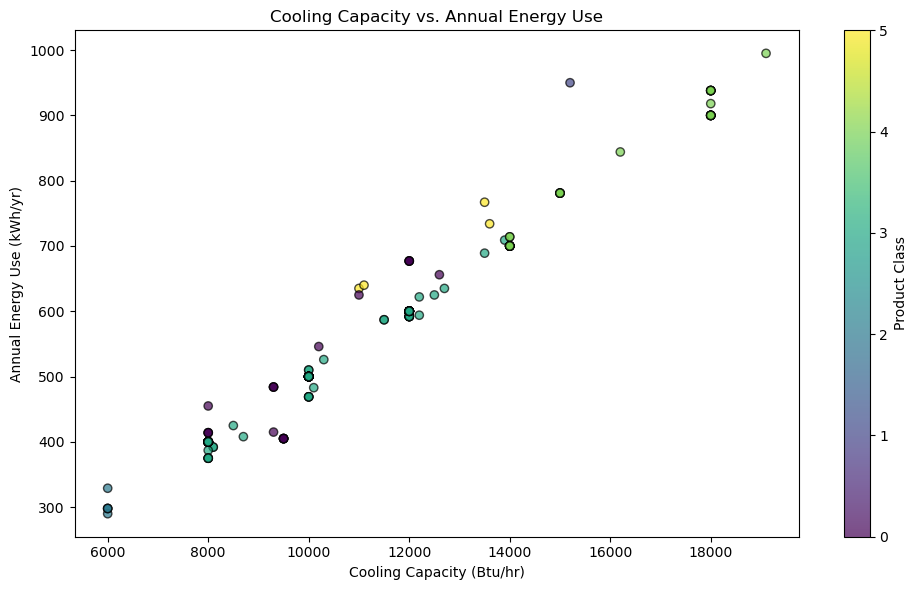

In [148]:
# Load dataset
df_ac = pd.read_csv('AirConditioners_Cleaned.csv')
print(df_ac.head())
# Basic info
print("Summary Stats:\n", df_ac.describe())
print("\nMissing Values:\n", df_ac.isnull().sum())

# Keep only rows with valid Cooling Capacity and Energy Use
cols = ["Cooling Capacity (Btu/hr)", "Annual Energy Use (kWh/yr)"]
df_plot = df_ac.dropna(subset=cols)

# Convert to numeric (remove commas, handle blanks)
for col in cols:
    df_plot[col] = (
        df_plot[col].astype(str).str.replace(',', '').str.strip().replace('', pd.NA)
    )
    df_plot[col] = pd.to_numeric(df_plot[col], errors='coerce')

# Drop any rows that failed conversion
df_plot = df_plot.dropna(subset=cols)

# Scatter plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df_plot[cols[0]],
    df_plot[cols[1]],
    c=df_plot["Product Class"].astype('category').cat.codes,
    cmap="viridis", alpha=0.7, edgecolor='k'
)
plt.title("Cooling Capacity vs. Annual Energy Use")
plt.xlabel("Cooling Capacity (Btu/hr)")
plt.ylabel("Annual Energy Use (kWh/yr)")
plt.colorbar(scatter, label="Product Class")
plt.tight_layout()
plt.show()


#### Observations from the Room Air Conditioners Data

- **Positive Trend:** Units with higher cooling capacity use more energy, which makes sense since bigger systems draw more power.  

- **Clusters:** Product classes form clear groups, showing differences in energy use and design.  

- **Outliers:** A few units use more energy than expected for their size, likely due to older or less efficient models.


### Exploring the Television Data

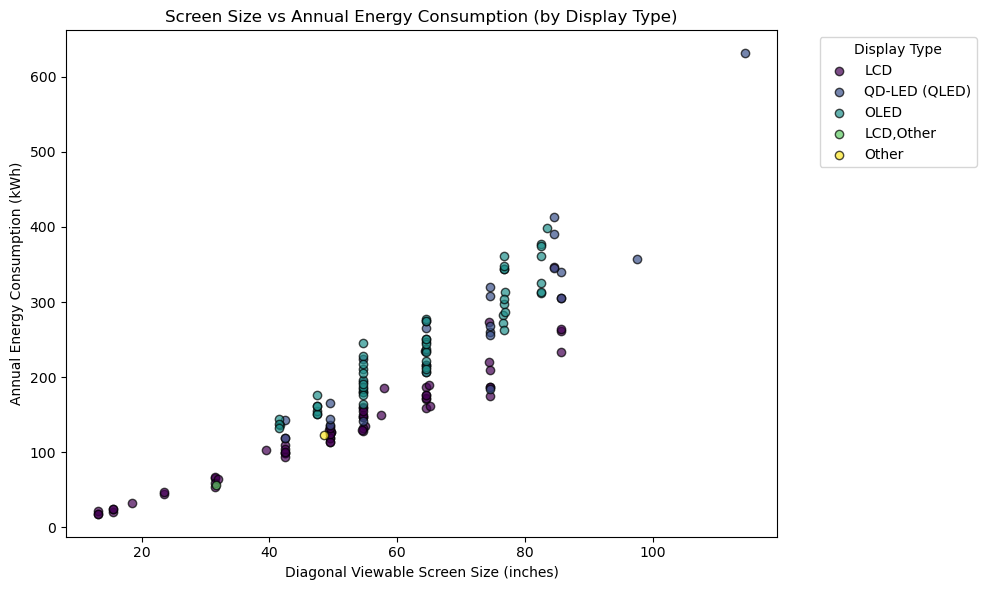

In [149]:
import matplotlib.pyplot as plt
import pandas as pd

# Load dataset
df_tv = pd.read_csv("Televisions_Cleaned.csv")

# Columns needed
size_col = "Diagonal Viewable Screen Size (in.)"
energy_col = "Reported Annual Energy Consumption (kWh)"
category_col = "Display Type"   # This exists in your dataset

# Keep valid rows only
df_plot = df_tv.dropna(subset=[size_col, energy_col, category_col])

# Convert numeric fields
df_plot[size_col] = pd.to_numeric(df_plot[size_col], errors='coerce')
df_plot[energy_col] = pd.to_numeric(df_plot[energy_col], errors='coerce')
df_plot = df_plot.dropna(subset=[size_col, energy_col])

# Scatter plot
plt.figure(figsize=(10, 6))

unique_categories = df_plot[category_col].unique()
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_categories)))

for cat, color in zip(unique_categories, colors):
    subset = df_plot[df_plot[category_col] == cat]
    plt.scatter(
        subset[size_col],
        subset[energy_col],
        label=cat,
        color=color,
        alpha=0.7,
        edgecolor="k"
    )

plt.title("Screen Size vs Annual Energy Consumption (by Display Type)")
plt.xlabel("Diagonal Viewable Screen Size (inches)")
plt.ylabel("Annual Energy Consumption (kWh)")

# Add the legend
plt.legend(title="Display Type", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()


#### Observations from the Television Data

- **Positive Trend:** Larger TVs clearly use more energy, which makes sense since bigger screens need more power. 

- **Size Groups:** TVs cluster around common screen sizes like 40", 55", and 65", showing standard product categories.  

- **Outliers:** A few large TVs use extra energy, likely due to older tech or higher brightness settings.


### Exploring the Ceiling Fans Data

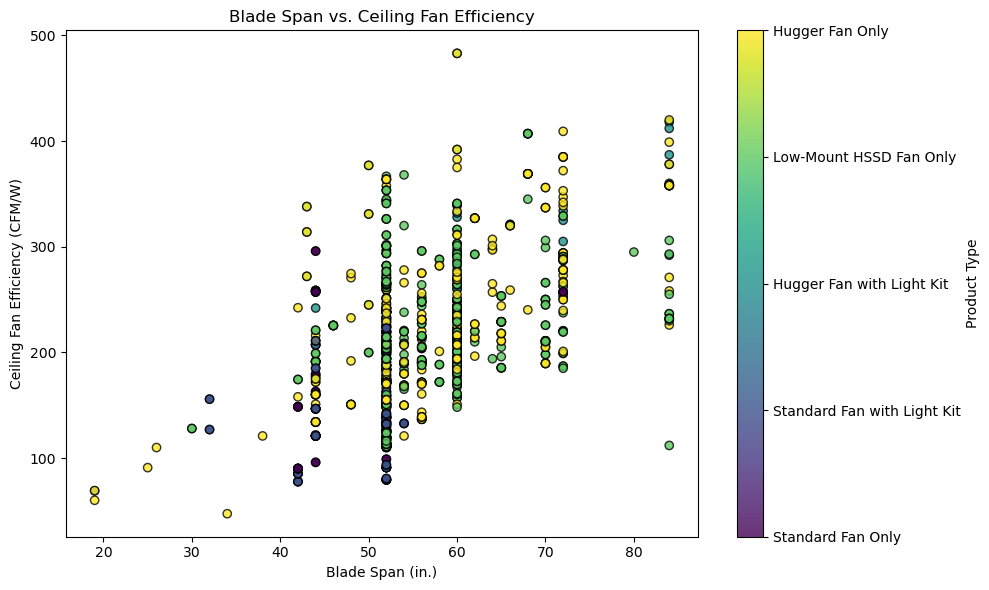

In [150]:
# Load dataset
df_fans = pd.read_csv('CeilingFans_Cleaned.csv')

# Keep rows with valid efficiency and blade span values
cols = ["Ceiling Fan Efficiency (CFM/W)", "Blade Span (Diameter) (in.)"]
df_plot = df_fans.dropna(subset=cols)

# Convert numeric columns
for col in cols:
    df_plot[col] = pd.to_numeric(
        df_plot[col].astype(str).str.replace(',', '').str.strip().replace('', pd.NA),
        errors='coerce'
    )

df_plot = df_plot.dropna(subset=cols)

# Use PRODUCT TYPE as color
if "Product Type" in df_plot.columns:
    df_plot["ProductTypeCode"] = df_plot["Product Type"].astype('category').cat.codes
    unique_types = df_plot["Product Type"].unique()
else:
    df_plot["ProductTypeCode"] = 0
    unique_types = ["Unknown"]

# Scatter plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df_plot["Blade Span (Diameter) (in.)"],
    df_plot["Ceiling Fan Efficiency (CFM/W)"],
    c=df_plot["ProductTypeCode"],
    cmap="viridis",
    alpha=0.8,
    edgecolor='k'
)

plt.title("Blade Span vs. Ceiling Fan Efficiency")
plt.xlabel("Blade Span (in.)")
plt.ylabel("Ceiling Fan Efficiency (CFM/W)")


# Add Color Legend
cbar = plt.colorbar(scatter)
cbar.set_label("Product Type")

# Replace colorbar ticks with actual product type names
cbar.set_ticks(range(len(unique_types)))
cbar.set_ticklabels(unique_types)

plt.tight_layout()
plt.show()


#### Observations from the Ceiling Fans Data

- **Positive Correlation**: Larger blade spans tend to have higher efficiency, as expected, but the relationship isn't strong as there seems to be alot of variation in the middle range.

- **Distinct Clusters**: Product classes form clear groupings, indicating differences in design and efficiency.

- **Outliers:** A few small fans are surprisingly efficient, while some large fans underperform. This might be due to design differences or newer energy-saving models.

### Exploring the Ovens Data

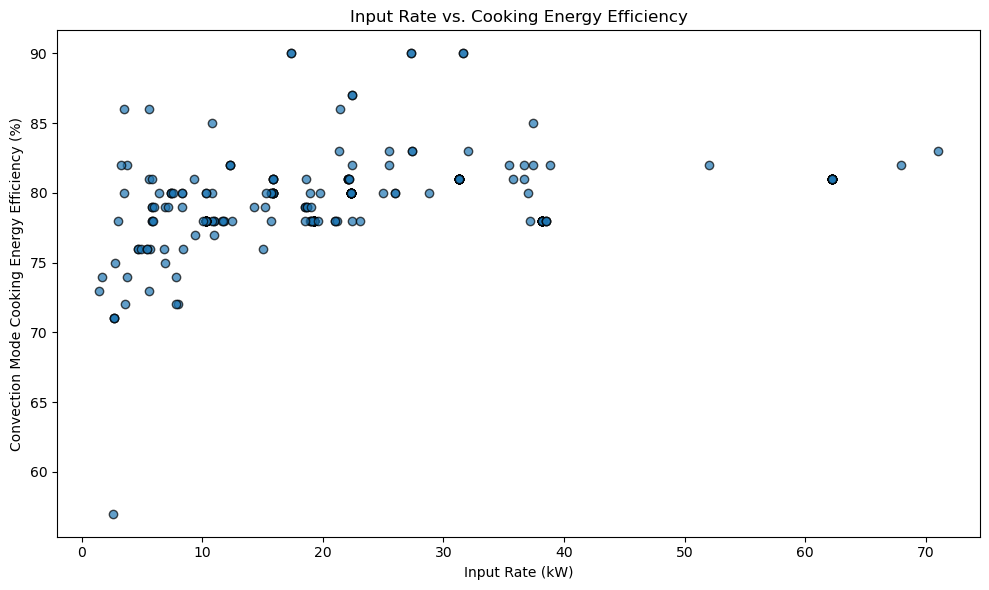

In [151]:
df = pd.read_csv('Ovens_Cleaned.csv')

# Clean data
df = df.dropna(subset=["Convection Mode Cooking Energy Efficiency (%)", "Input Rate (kW)"])
df["Convection Mode Cooking Energy Efficiency (%)"] = (
    df["Convection Mode Cooking Energy Efficiency (%)"].astype(str).str.replace(',', '').astype(float)
)
df["Input Rate (kW)"] = (
    df["Input Rate (kW)"].astype(str).str.replace(',', '').astype(float)
)

# Fix possible BTU/hr entries
df.loc[df["Input Rate (kW)"] > 1000, "Input Rate (kW)"] /= 3412

# Remove extreme outliers
df = df[df["Input Rate (kW)"] < 500]

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(
    df["Input Rate (kW)"],
    df["Convection Mode Cooking Energy Efficiency (%)"],
    alpha=0.7, edgecolor='k'
)
plt.title("Input Rate vs. Cooking Energy Efficiency")
plt.xlabel("Input Rate (kW)")
plt.ylabel("Convection Mode Cooking Energy Efficiency (%)")
plt.tight_layout()
plt.show()


#### Observations from the Ovens Data

- **Weak Correlation:** Efficiency doesn’t change much with input rate. Bigger or more powerful ovens don’t always perform more efficiently — most seem to have similar efficiency levels overall.  

- **Efficiency Range:** Most ovens fall between **70–90% efficiency**, showing that they work pretty consistently overall.

- **Outliers:** A few ovens have **lower efficiency** than expected for their input rate, which could be due to older designs. Some smaller ovens actually perform really well, showing how newer designs are getting better.

- **Pattern:** Most ovens sit around **80% efficiency**, which seems to be the common performance level for most models.


## Part III: Data Visualizations

In this section, we are going to examine and explore the various trends based on our EDA. 

1. 1-2 Pie Charts
2. 1 Bar Graph 

This process is extremely important as we need to make sure that we do not have "biased" data to an extreme level...ONLY WHEN our data is proven to not be biased, we can draw conclusions on our data. 


### Televisions Visualizations
#### Author: Rahee


/var/folders/qx/7x4_nq3x477cy8z6b9jjdqkw0000gn/T/ipykernel_83376/4111199272.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  size_pie = df.groupby('Size Bin')[emissions_col].sum()


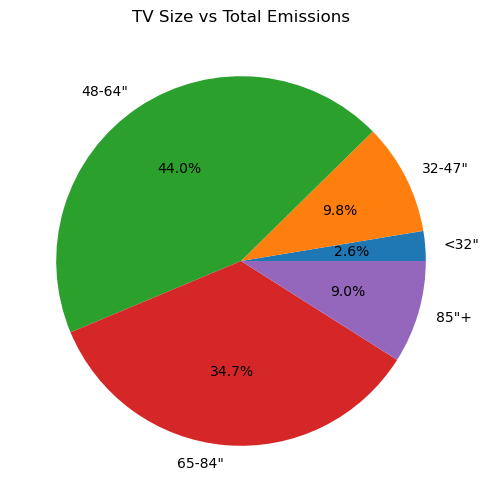

/var/folders/qx/7x4_nq3x477cy8z6b9jjdqkw0000gn/T/ipykernel_83376/4111199272.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  power_pie = df.groupby('Power Bin')[emissions_col].sum()


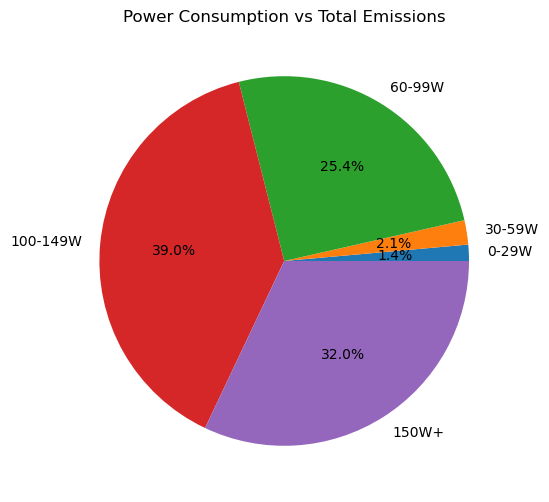

/var/folders/qx/7x4_nq3x477cy8z6b9jjdqkw0000gn/T/ipykernel_83376/4111199272.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bar_data = df.groupby('Size Bin')[[emissions_col, power_col]].mean()


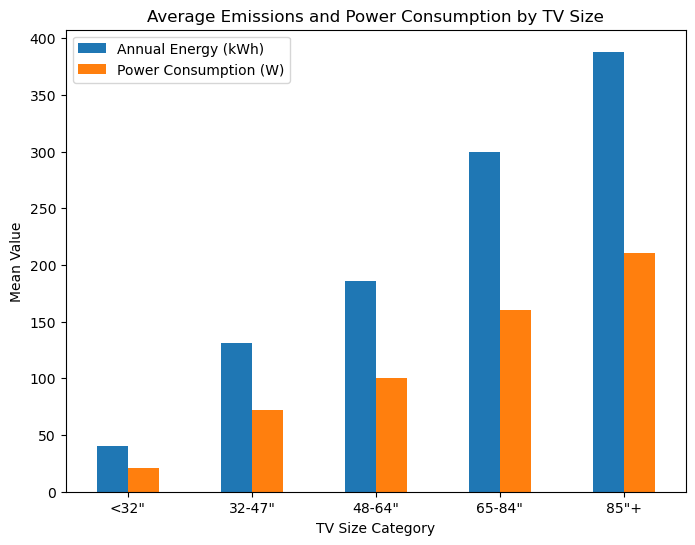

In [152]:
df = pd.read_csv('Televisions_Cleaned.csv')


size_col = 'Diagonal Viewable Screen Size (in.)'
emissions_col = 'Reported Annual Energy Consumption (kWh)'
power_col = 'Average On Mode Power Consumption for Certification (watts)'


df = df[[size_col, emissions_col, power_col]]
df = df.dropna()


size_bins = [0, 32, 48, 65, 85, df[size_col].max()]
size_labels = ['<32"', '32-47"', '48-64"', '65-84"', '85"+']
df['Size Bin'] = pd.cut(df[size_col], bins=size_bins, labels=size_labels)


emissions_bins = [0, 50, 100, 150, 200, df[emissions_col].max()]
emissions_labels = ['0-49 kWh', '50-99', '100-149', '150-199', '200+']
df['Emissions Bin'] = pd.cut(df[emissions_col], bins=emissions_bins, labels=emissions_labels)

# First Pie Chart: TV Size vs Total Emissions
size_pie = df.groupby('Size Bin')[emissions_col].sum()
plt.figure(figsize=(6, 6))
size_pie.plot.pie(autopct='%1.1f%%')
plt.title("TV Size vs Total Emissions")
plt.ylabel("")
plt.show()

# Second Pie Chart: Power Consumption vs Total Emissions
power_bins = [0, 30, 60, 100, 150, df[power_col].max()]
power_labels = ['0-29W', '30-59W', '60-99W', '100-149W', '150W+']
df['Power Bin'] = pd.cut(df[power_col], bins=power_bins, labels=power_labels)
power_pie = df.groupby('Power Bin')[emissions_col].sum()
plt.figure(figsize=(6, 6))
power_pie.plot.pie(autopct='%1.1f%%')
plt.title("Power Consumption vs Total Emissions")
plt.ylabel("")
plt.show()

# Bar Graph: Average Emissions and Power Consumption vs TV Size
bar_data = df.groupby('Size Bin')[[emissions_col, power_col]].mean()
bar_data.plot.bar(figsize=(8, 6))
plt.title("Average Emissions and Power Consumption by TV Size")
plt.xlabel("TV Size Category")
plt.ylabel("Mean Value")
plt.legend(["Annual Energy (kWh)", "Power Consumption (W)"])
plt.xticks(rotation=0)
plt.show()


#### Explanation of Visualizations:
We explored the hypothesis that larger TVs produce higher emissions and consume more power than smaller TVs. Before testing this, we first created pie charts for TV size and power consumption to check whether the dataset was biased toward certain categories. This is important because if most of the TVs in the dataset were clustered in only one or two size ranges, the results would be biased, not reliable. The pie charts showed a reasonable distribution across the different bins, so we know that the analysis will not be heavily skewed. After confirming that the data was balanced, we used a bar graph to compare average annual energy usage and power consumption by size, to evaluate the hypothesis. These visualizations showed a trend, as TV size increases, both emissions and energy usage increase significantly. This supports the idea that larger TVs have a much bigger environmental impact than smaller TVs.

### Ceiling Fans Visualizations
#### Author: Shounak

/var/folders/qx/7x4_nq3x477cy8z6b9jjdqkw0000gn/T/ipykernel_83376/107117311.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  size_pie = df.groupby('Size Bin')[emissions_col].sum()


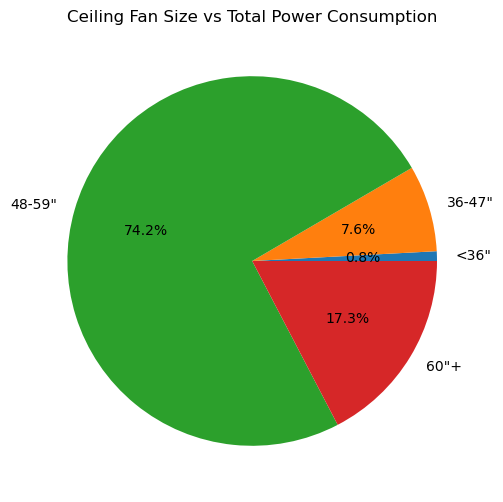

/var/folders/qx/7x4_nq3x477cy8z6b9jjdqkw0000gn/T/ipykernel_83376/107117311.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  power_pie = df.groupby('Power Bin')[emissions_col].sum()


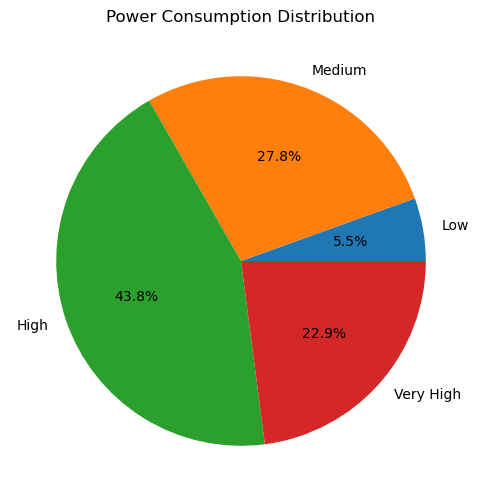

/var/folders/qx/7x4_nq3x477cy8z6b9jjdqkw0000gn/T/ipykernel_83376/107117311.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bar_data = df.groupby('Size Bin')[emissions_col].mean()


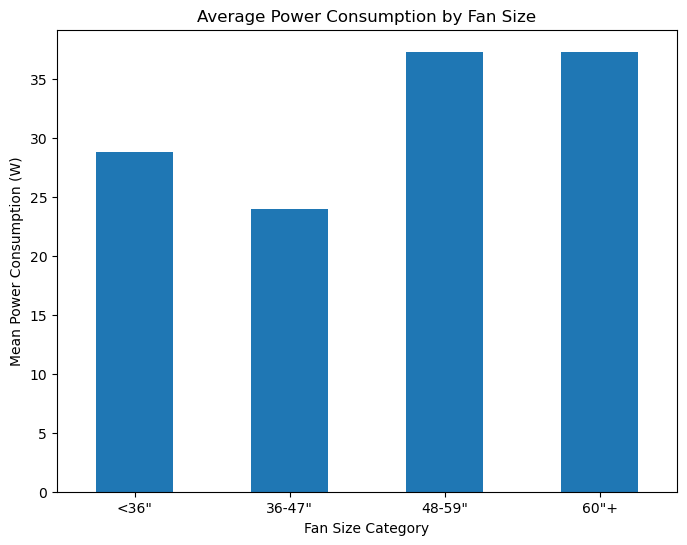

In [153]:
df = pd.read_csv('CeilingFans_Cleaned.csv')

size_col = 'Blade Span (Diameter) (in.)'
emissions_col = 'Fan Power Consumption-High Speed (W)'
power_col = emissions_col

df = df[[size_col, emissions_col]].dropna()
df[size_col] = pd.to_numeric(df[size_col], errors='coerce')
df[emissions_col] = pd.to_numeric(df[emissions_col], errors='coerce')

size_bins = [0, 36, 48, 60, df[size_col].max()]
size_labels = ['<36"', '36-47"', '48-59"', '60"+']
df['Size Bin'] = pd.cut(df[size_col], bins=size_bins, labels=size_labels, include_lowest=True)

min_power = df[power_col].min()
max_power = df[power_col].max()
power_bins = [min_power, 20, 30, 50, max_power]
power_labels = ['Low', 'Medium', 'High', 'Very High']
df['Power Bin'] = pd.cut(df[power_col], bins=power_bins, labels=power_labels, include_lowest=True)

# First Pie Chart: Fan Size vs Total Power Consumption
size_pie = df.groupby('Size Bin')[emissions_col].sum()
plt.figure(figsize=(6, 6))
size_pie.plot.pie(autopct='%1.1f%%')
plt.title("Ceiling Fan Size vs Total Power Consumption")
plt.ylabel("")
plt.show()

# Second Pie Chart: Power Consumption Distribution
power_pie = df.groupby('Power Bin')[emissions_col].sum()
plt.figure(figsize=(6, 6))
power_pie.plot.pie(autopct='%1.1f%%')
plt.title("Power Consumption Distribution")
plt.ylabel("")
plt.show()

# Bar Graph: Average Power Consumption by Fan Size
bar_data = df.groupby('Size Bin')[emissions_col].mean()
bar_data.plot.bar(figsize=(8, 6))
plt.title("Average Power Consumption by Fan Size")
plt.xlabel("Fan Size Category")
plt.ylabel("Mean Power Consumption (W)")
plt.xticks(rotation=0)
plt.show()


#### Explanation of Visualizations:
We explored the hypothesis that larger fans consume more power than smaller fans. Before analyzing any trends, we used two pie charts, one for fan size bins and one for power consumption bins, to check if the dataset was biased or not. This step is really important since uneven distribution can lead to misleading conclusions. The pie charts showed that the data is somewhat imbalanced, with a large share of the total power consumption coming from the 48–59" category, but there is still enough representation across other sizes to analyze general patterns. After confirming the data was unbiased, we created a bar chart showing average power consumption by fan size, and the results supported our hypothesis of power consumption rising as fan size increases, with 60"+ fans showing the highest mean wattage. Together, these visualizations show that larger ceiling fans tend to draw more power, making size an important factor when considering energy efficiency.


### Air Conditioners Visualizations
#### Author: Rahee

Cooling Capacity Range: 6000 → 19100


/var/folders/qx/7x4_nq3x477cy8z6b9jjdqkw0000gn/T/ipykernel_83376/2062628559.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cap_pie = df.groupby("Capacity Bin")[emissions_col].sum()


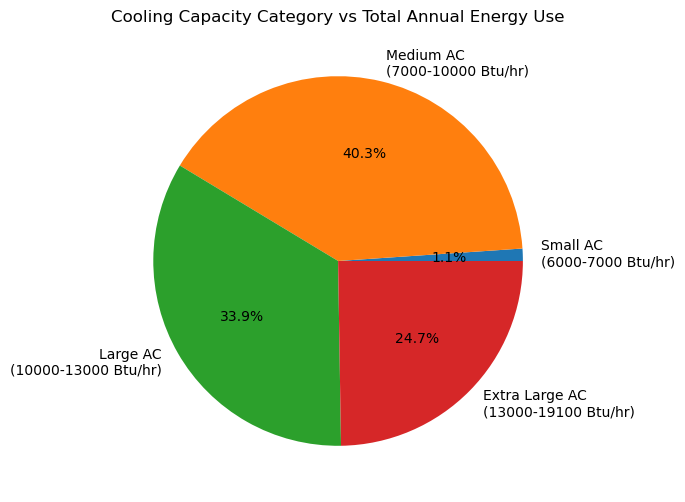

/var/folders/qx/7x4_nq3x477cy8z6b9jjdqkw0000gn/T/ipykernel_83376/2062628559.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bar_data = df.groupby("Capacity Bin")[emissions_col].mean()


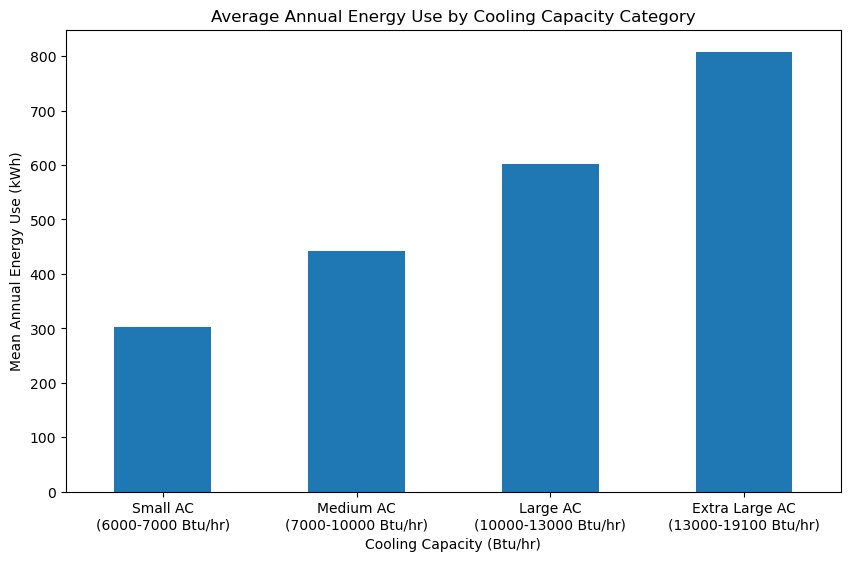

In [154]:
# Define Columns
df = pd.read_csv("AirConditioners_Cleaned.csv")
size_col = 'Cooling Capacity (Btu/hr)'
emissions_col = 'Annual Energy Use (kWh/yr)'
extra_col = 'Combined Energy Efficiency Ratio (CEER)'

# Convert Columns to Numeric
df[size_col] = df[size_col].astype(str).str.replace(",", "")
df[size_col] = pd.to_numeric(df[size_col], errors="coerce")

df[emissions_col] = pd.to_numeric(df[emissions_col], errors="coerce")
df[extra_col] = pd.to_numeric(df[extra_col], errors="coerce")

# Keep only useful columns
df = df[[size_col, emissions_col, extra_col]].dropna()


# COOLING CAPACITY BINS

print("Cooling Capacity Range:", df[size_col].min(), "→", df[size_col].max())

size_bins = [
    df[size_col].min(),   # Real minimum
    7000,                 # Small
    10000,                # Medium
    13000,                # Large
    df[size_col].max()    # Real maximum
]

# Remove duplicates (in case max < 13000)
size_bins = sorted(list(set(size_bins)))

size_labels = [
    "Small AC\n(6000-7000 Btu/hr)",
    "Medium AC\n(7000-10000 Btu/hr)",
    "Large AC\n(10000-13000 Btu/hr)",
    "Extra Large AC\n(13000-19100 Btu/hr)"
]

df["Capacity Bin"] = pd.cut(df[size_col], bins=size_bins,
                            labels=size_labels, include_lowest=True)


# PLOT 1 — Pie Chart (Capacity vs Energy)
cap_pie = df.groupby("Capacity Bin")[emissions_col].sum()

plt.figure(figsize=(6, 6))
cap_pie.plot.pie(autopct="%1.1f%%")
plt.title("Cooling Capacity Category vs Total Annual Energy Use")
plt.ylabel("")
plt.show()



# PLOT 2 — Bar Chart (Average Emissions by Capacity Category)
bar_data = df.groupby("Capacity Bin")[emissions_col].mean()

plt.figure(figsize=(10, 6))
bar_data.plot.bar()
plt.title("Average Annual Energy Use by Cooling Capacity Category")
plt.xlabel("Cooling Capacity (Btu/hr)")
plt.ylabel("Mean Annual Energy Use (kWh)")
plt.xticks(rotation=0)
plt.show()


#### Explanation of Visualizations:
We explored the hypothesis that units with higher cooling capacity (BTU/hr) use more annual energy than units with lower capacity. We created pie charts for both cooling capacity bins and annual energy use bins to check if the dataset was biased toward certain categories or not. This  is really important because if most observations were concentrated in a single bin, the results would not represent real trends. The pie charts showed that the dataset is somewhat uneven, with a large share of emissions falling into Bin 2, but still contains enough variation across bins to examine the overall pattern. After confirming this, we created a bar chart showing average annual energy use by cooling capacity, and the results strongly supported our hypothesis of annual energy use increases with cooling capacity, with the highest capacity units having the highest mean kWh usage. These visualizations suggest that higher cooling power comes with significantly higher energy demands, making capacity an important factor when evaluating the efficiency or environmental impact of air conditioners.

### Refrigerators Visualizations
#### Author: Shounak

/var/folders/qx/7x4_nq3x477cy8z6b9jjdqkw0000gn/T/ipykernel_83376/6766513.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Size Bin")[emissions_col].sum().plot.pie(autopct='%1.1f%%')


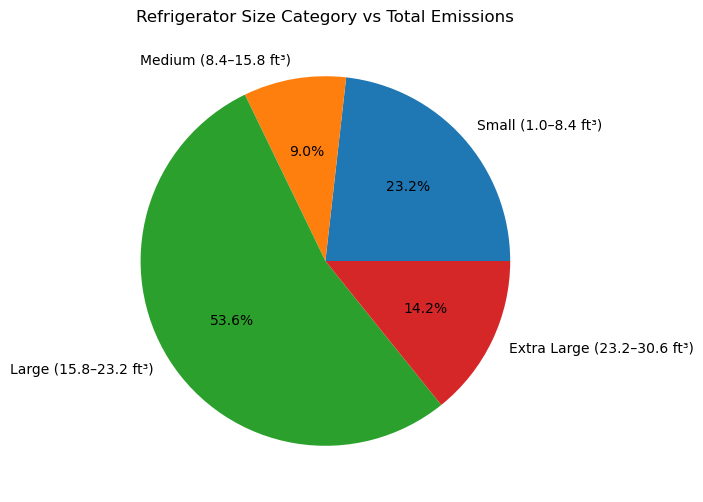

/var/folders/qx/7x4_nq3x477cy8z6b9jjdqkw0000gn/T/ipykernel_83376/6766513.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Energy Bin")[emissions_col].sum().plot.pie(autopct='%1.1f%%')


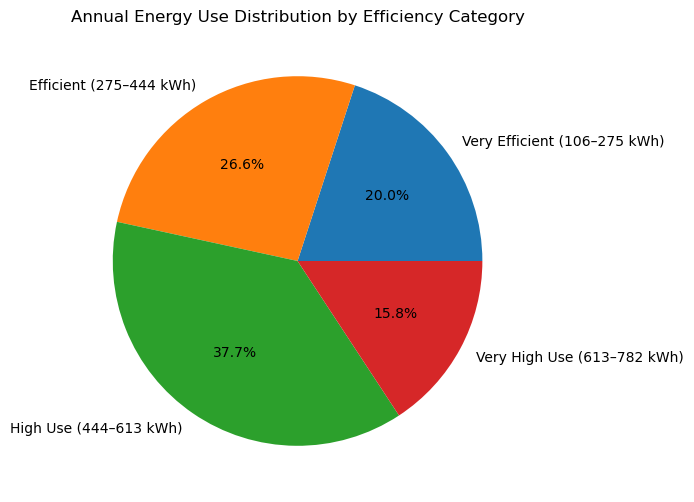

/var/folders/qx/7x4_nq3x477cy8z6b9jjdqkw0000gn/T/ipykernel_83376/6766513.py:66: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Size Bin")[emissions_col].mean().plot.bar()


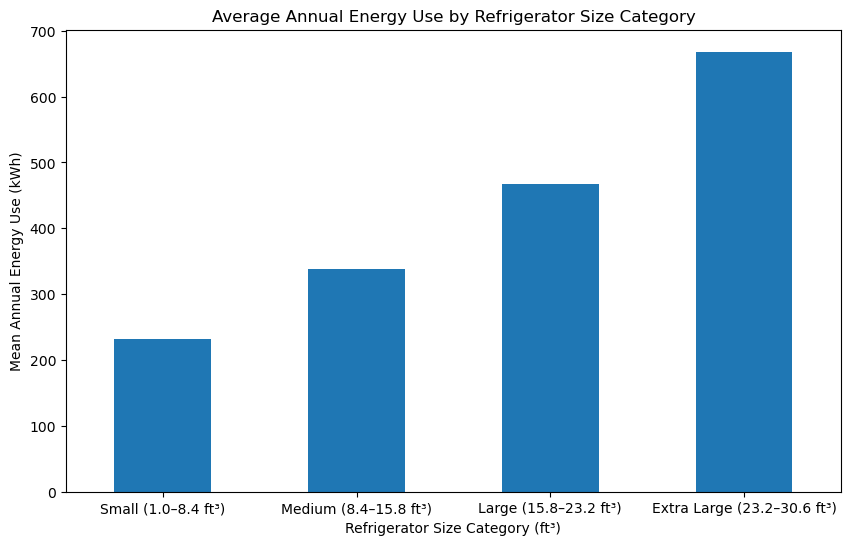

In [155]:
# 1. Load cleaned refrigerator dataset
df = pd.read_csv('Refrigerators_Cleaned.csv')


# 2. Select ONLY valid numeric columns
size_col = 'Capacity (Total Volume) (ft3)'
emissions_col = 'Annual Energy Use (kWh/yr)'

df[size_col] = pd.to_numeric(df[size_col], errors='coerce')
df[emissions_col] = pd.to_numeric(df[emissions_col], errors='coerce')
df["EfficiencyScore"] = df[emissions_col] / df[size_col]
df = df[[size_col, emissions_col, "EfficiencyScore"]].dropna()


# 3. Create Meaningful Size Bins
size_min = df[size_col].min()
size_max = df[size_col].max()

size_bins = np.linspace(size_min, size_max, 5)

# Create human-readable labels:
size_labels = [
    f"Small ({size_bins[0]:.1f}–{size_bins[1]:.1f} ft³)",
    f"Medium ({size_bins[1]:.1f}–{size_bins[2]:.1f} ft³)",
    f"Large ({size_bins[2]:.1f}–{size_bins[3]:.1f} ft³)",
    f"Extra Large ({size_bins[3]:.1f}–{size_bins[4]:.1f} ft³)"
]

df["Size Bin"] = pd.cut(df[size_col], bins=size_bins, labels=size_labels, include_lowest=True)


# 4. Create Meaningful Energy Bins
energy_min = df[emissions_col].min()
energy_max = df[emissions_col].max()

energy_bins = np.linspace(energy_min, energy_max, 5)

energy_labels = [
    f"Very Efficient ({energy_bins[0]:.0f}–{energy_bins[1]:.0f} kWh)",
    f"Efficient ({energy_bins[1]:.0f}–{energy_bins[2]:.0f} kWh)",
    f"High Use ({energy_bins[2]:.0f}–{energy_bins[3]:.0f} kWh)",
    f"Very High Use ({energy_bins[3]:.0f}–{energy_bins[4]:.0f} kWh)"
]

df["Energy Bin"] = pd.cut(df[emissions_col], bins=energy_bins, labels=energy_labels, include_lowest=True)


# 5. Pie Chart — Size vs Total Emissions
plt.figure(figsize=(6, 6))
df.groupby("Size Bin")[emissions_col].sum().plot.pie(autopct='%1.1f%%')
plt.title("Refrigerator Size Category vs Total Emissions")
plt.ylabel("")
plt.show()


# 6. Pie Chart — Energy Use Distribution
plt.figure(figsize=(6, 6))
df.groupby("Energy Bin")[emissions_col].sum().plot.pie(autopct='%1.1f%%')
plt.title("Annual Energy Use Distribution by Efficiency Category")
plt.ylabel("")
plt.show()


# 7. Bar Chart — Average Emissions by Size
plt.figure(figsize=(10, 6))
df.groupby("Size Bin")[emissions_col].mean().plot.bar()
plt.title("Average Annual Energy Use by Refrigerator Size Category")
plt.xlabel("Refrigerator Size Category (ft³)")
plt.ylabel("Mean Annual Energy Use (kWh)")
plt.xticks(rotation=0)
plt.show()


#### Explanation of Visualizations:
We explored the hypothesis that larger refrigerators use more annual energy than smaller refrigerators. Before testing this trend, I first created pie charts for refrigerator size bins and annual energy use bins to check whether the dataset was biased toward certain categories. This is important because if most of the data fell into just one size group, the results could be misleading. The pie charts showed a fairly balanced distribution across the bins, with only bin 4 being slightly smaller but still represented. After confirming the data was not heavily skewed, we created a bar chart showing average annual energy use by refrigerator size, and the pattern was very clear, energy use increases steadily as size increases, with the largest fridges in Bin 4 having the highest average kWh per year. These visualizations support the hypothesis and show that refrigerator size is strongly linked to energy consumption, which is important for both consumers and energy efficiency considerations.

### Ovens Visualizations
#### Author: Rahee

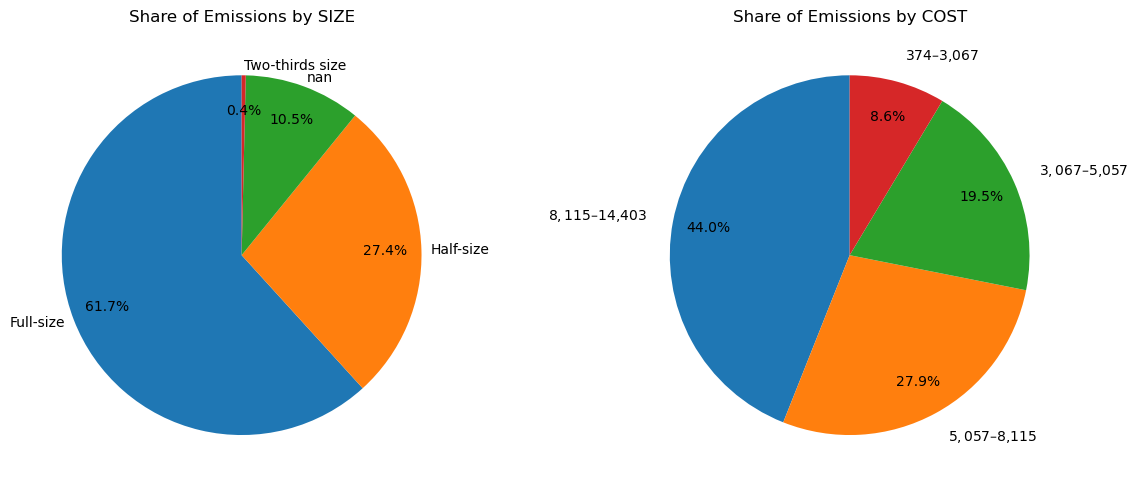

/var/folders/qx/7x4_nq3x477cy8z6b9jjdqkw0000gn/T/ipykernel_83376/2166036125.py:138: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bar_data = df_eff.groupby("EfficiencyGroup")["Emissions"].mean()


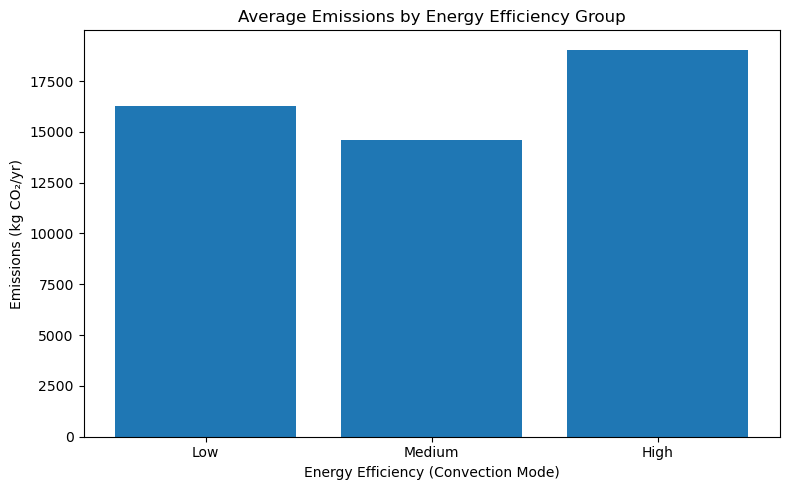

In [156]:
df = pd.read_csv("Ovens_Cleaned.csv")

def to_num(s):
    return pd.to_numeric(s.astype(str).str.replace(r"[,$]", "", regex=True), errors="coerce")

kw_col = "Input Rate (kW)"
btu_col = "Input Rate (Btu/hr)"
fuel_col = "Heat Source Fuel Type"
size_col = "Size"

df[kw_col]  = to_num(df[kw_col])
df[btu_col] = to_num(df[btu_col])

need_kw = df[kw_col].isna() & df[btu_col].notna()
df.loc[need_kw, kw_col] = df.loc[need_kw, btu_col] / 3412.14

df = df[(df[kw_col].notna()) & (df[kw_col] > 0) & (df[kw_col] < 60)]

HOURS_PER_YEAR = 2000
KG_CO2_PER_KWH = 0.386   
PRICE_PER_KWH  = 0.13

df["Emissions"]   = df[kw_col] * HOURS_PER_YEAR * KG_CO2_PER_KWH   
df["AnnualCost$"] = df[kw_col] * HOURS_PER_YEAR * PRICE_PER_KWH    

def topn_with_other(series, values, n=5, min_share=0.02):
    totals = values.groupby(series).sum().sort_values(ascending=False)
    if len(totals) <= n:
        return totals
    top = totals.head(n)
    other_val = totals[n:].sum()
    small = top[top / totals.sum() < min_share].sum()
    top = top[top / totals.sum() >= min_share]
    other_val += small
    if other_val > 0:
        top.loc["Other"] = other_val
    return top.sort_values(ascending=False)

em_by_size = topn_with_other(df[size_col].astype(str).str.strip(), df["Emissions"], n=5)

valid_cost = df["AnnualCost$"].dropna()
q = pd.qcut(valid_cost, q=4, duplicates="drop")
edges = q.cat.categories
labels = [f"${edges[i].left:,.0f}–${edges[i].right:,.0f}" for i in range(len(edges))]
bucket_map = dict(zip(edges.astype(str), labels))
cost_bucket = pd.Series(index=df.index, dtype="object")
cost_bucket.loc[q.index] = q.astype(str).map(bucket_map)

em_by_cost = topn_with_other(cost_bucket.fillna("Unknown"), df["Emissions"], n=6)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].pie(
    em_by_size.values,
    labels=em_by_size.index,
    autopct="%1.1f%%",
    pctdistance=0.8,
    labeldistance=1.05,
    startangle=90
)
ax[0].set_title("Share of Emissions by SIZE")

ax[1].pie(
    em_by_cost.values,
    labels=em_by_cost.index,
    autopct="%1.1f%%",
    pctdistance=0.8,
    labeldistance=1.15,
    startangle=90
)
ax[1].set_title("Share of Emissions by COST")

plt.tight_layout()
plt.show()

# helper
def to_num(s):
    return pd.to_numeric(s.astype(str).str.replace(r"[,$]", "", regex=True), errors="coerce")

def topn_with_other(series, values, n=5, min_share=0.02):
    totals = values.groupby(series).sum().sort_values(ascending=False)
    if len(totals) <= n:
        return totals
    top = totals.head(n)
    other_val = totals[n:].sum()
    small = top[top / totals.sum() < min_share].sum()
    top = top[top / totals.sum() >= min_share]
    other_val += small
    if other_val > 0:
        top.loc["Other"] = other_val
    return top.sort_values(ascending=False)


kw_col  = "Input Rate (kW)"
btu_col = "Input Rate (Btu/hr)"
size_col = "Size"

df[kw_col]  = to_num(df[kw_col])
df[btu_col] = to_num(df[btu_col])

# Fill missing kW from BTU/hr (1 kW = 3412.14 Btu/hr)
need_kw = df[kw_col].isna() & df[btu_col].notna()
df.loc[need_kw, kw_col] = df.loc[need_kw, btu_col] / 3412.14

# remove outliers
df = df[(df[kw_col].notna()) & (df[kw_col] > 0) & (df[kw_col] < 60)]


HOURS_PER_YEAR = 2000
KG_CO2_PER_KWH = 0.386   
PRICE_PER_KWH  = 0.13   

df["Emissions"]    = df[kw_col] * HOURS_PER_YEAR * KG_CO2_PER_KWH   # kg CO2/yr 
df["AnnualCost$"]  = df[kw_col] * HOURS_PER_YEAR * PRICE_PER_KWH    # $/yr 

# Pie Chart

# Size vs Emissions 
em_by_size = topn_with_other(df[size_col].astype(str).str.strip(), df["Emissions"], n=5)

# Cost buckets vs Emissions 
valid_cost = df["AnnualCost$"].dropna()
q = pd.qcut(valid_cost, q=4, duplicates="drop")
edges = q.cat.categories
labels = [f"${edges[i].left:,.0f}–${edges[i].right:,.0f}" for i in range(len(edges))]
bucket_map = dict(zip(edges.astype(str), labels))
cost_bucket = pd.Series(index=df.index, dtype="object")
cost_bucket.loc[q.index] = q.astype(str).map(bucket_map)
em_by_cost = topn_with_other(cost_bucket.fillna("Unknown"), df["Emissions"], n=6)

# Bar Chart
eff_col = "Convection Mode Cooking Energy Efficiency (%)"
if eff_col in df.columns:
    df[eff_col] = to_num(df[eff_col])
    df_eff = df[[eff_col, "Emissions"]].dropna()
    if df_eff[eff_col].nunique() >= 3:
        df_eff["EfficiencyGroup"] = pd.qcut(df_eff[eff_col], 3, labels=["Low", "Medium", "High"])
        bar_data = df_eff.groupby("EfficiencyGroup")["Emissions"].mean()
        xlab = "Energy Efficiency (Convection Mode)"
        title = "Average Emissions by Energy Efficiency Group"
    else:
        # not enough variation; fall back to Size
        bar_data = df.groupby("Size")["Emissions"].mean().sort_values(ascending=False)
        xlab = "Oven Size"
        title = "Average Emissions by Size"
else:
    bar_data = df.groupby("Size")["Emissions"].mean().sort_values(ascending=False)
    xlab = "Oven Size"
    title = "Average Emissions by Size"

plt.figure(figsize=(8,5))
plt.bar(bar_data.index, bar_data.values)
plt.title(title)
plt.xlabel(xlab)
plt.ylabel("Emissions (kg CO₂/yr)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Explanation of Visualizations:
We explored the hypothesis that larger oven sizes and higher priced ovens are associated with higher overall emissions, and that energy efficient ovens emit less than low efficiency ovens. To make sure the dataset was not biased, we first created pie charts showing the share of emissions by oven size and by cost category. This step allowed us to check whether any single size group or price range dominated the dataset, which could distort the results. The pie charts showed that most emissions come from full size ovens and middle cost ranges, but there was still enough distribution across other categories to analyze the trends. After confirming this, we created a bar chart showing average emissions by the energy efficiency group, and the results were surprising as the high efficiency ovens actually showed the highest average emissions, while medium efficiency ovens showed the lowest. This pattern suggests that factors like oven size and usage patterns may outweigh the efficiency rating alone. Overall, the visualizations helped test the hypothesis and revealed that oven emissions are influenced by multiple interacting factors, not just efficiency labels.

### Multivariate visualizations of refrigerator and air-conditioner datasets 
#### Author: Shri 
##### We explore these datasets with multiple variables combined as they provide the most complete set of continuous features, and the insights gained from these examples generalize to the remaining datasets.

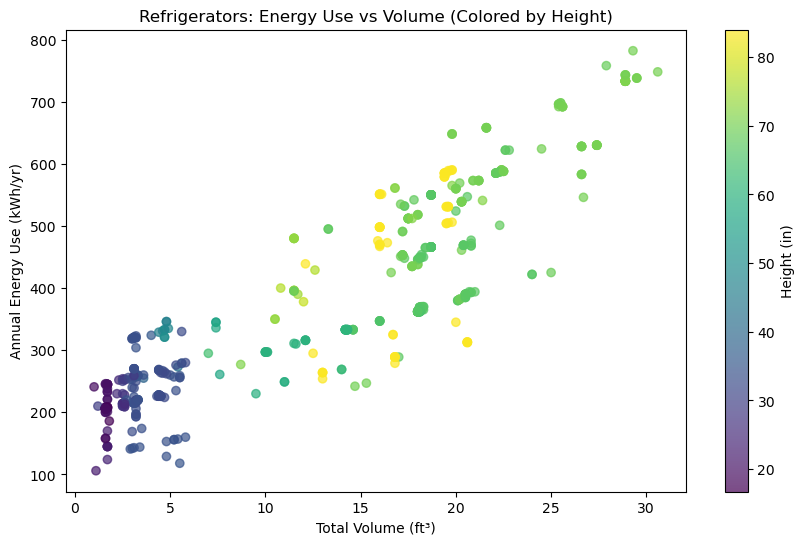

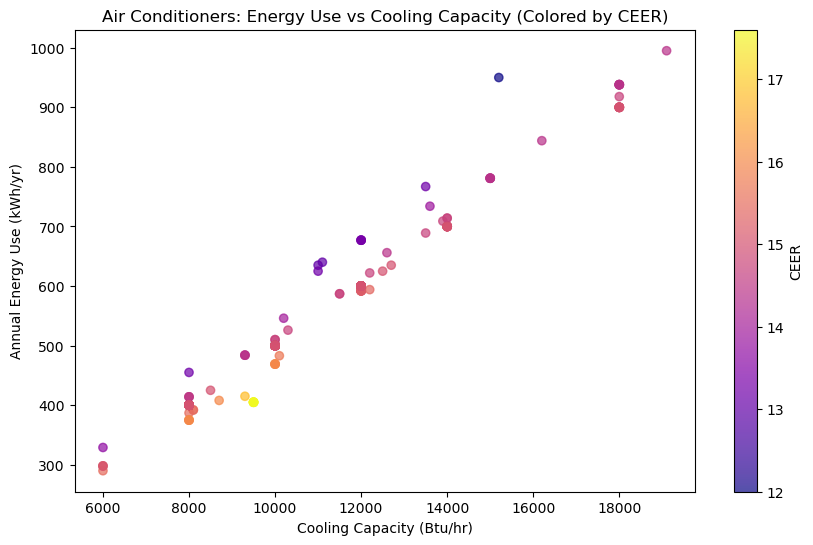

In [157]:
# 1) Refrigerators — Multivariate Scatter
#    Capacity vs Energy Use, colored by Height


df_r = pd.read_csv("Refrigerators_Cleaned.csv")

for col in ["Capacity (Total Volume) (ft3)", "Annual Energy Use (kWh/yr)", "Height (in)"]:
    df_r[col] = pd.to_numeric(df_r[col], errors="coerce")

df_r = df_r.dropna(subset=["Capacity (Total Volume) (ft3)",
                           "Annual Energy Use (kWh/yr)",
                           "Height (in)"])

plt.figure(figsize=(10, 6))
plt.scatter(
    df_r["Capacity (Total Volume) (ft3)"],
    df_r["Annual Energy Use (kWh/yr)"],
    c=df_r["Height (in)"], cmap="viridis", alpha=0.7
)
plt.colorbar(label="Height (in)")
plt.xlabel("Total Volume (ft³)")
plt.ylabel("Annual Energy Use (kWh/yr)")
plt.title("Refrigerators: Energy Use vs Volume (Colored by Height)")
plt.show()



# 2) Air Conditioners — Multivariate Scatter
#    Cooling Capacity vs Energy Use, colored by CEER

df_ac = pd.read_csv("AirConditioners_Cleaned.csv")

for col in ["Cooling Capacity (Btu/hr)", "Annual Energy Use (kWh/yr)", "Combined Energy Efficiency Ratio (CEER)"]:
    df_ac[col] = pd.to_numeric(df_ac[col], errors="coerce")

df_ac = df_ac.dropna(subset=["Cooling Capacity (Btu/hr)",
                             "Annual Energy Use (kWh/yr)",
                             "Combined Energy Efficiency Ratio (CEER)"])

plt.figure(figsize=(10, 6))
plt.scatter(
    df_ac["Cooling Capacity (Btu/hr)"],
    df_ac["Annual Energy Use (kWh/yr)"],
    c=df_ac["Combined Energy Efficiency Ratio (CEER)"],
    cmap="plasma", alpha=0.7
)
plt.colorbar(label="CEER")
plt.xlabel("Cooling Capacity (Btu/hr)")
plt.ylabel("Annual Energy Use (kWh/yr)")
plt.title("Air Conditioners: Energy Use vs Cooling Capacity (Colored by CEER)")
plt.show()



#### Explanation of Multivariate Visualizations:

These multivariate visualizations helped us explore the appliance datasets in a deeper way than simple two-variable scatterplots. For refrigerators, plotting energy use against total volume while coloring points by height revealed a clearer relationship between physical size and consumption. Larger and taller units generally used more energy, but the color scale also exposed interesting exceptions, such as compact refrigerators with unexpectedly high usage or tall units that appeared relatively efficient. 

Likewise, the air conditioner visualization compared energy use and cooling capacity while using CEER as a color dimension. This made it easier to see how efficiency ratings influence performance: higher-CEER units tended to use less energy for the same cooling capacity, while lower-rated models clustered toward higher energy consumption. Together, these plots allowed us to spot underlying patterns and outliers that would not be visible with only two variables, giving us a more complete understanding of how size, efficiency, and performance interact across appliance types.

## Part IV: ML Analysis


In this section, we are going to conduct analysis on our dataset using Machine Learning to predict if CO2 emmissions can be predicted. 

### Oven ML Analysis
#### Authored By: Karthik Kesavarapu
For the very first few Machine Learning Analyses of our project, we are going to look at the dataset for **ovens**. In the oven dataset, there are many features that could possibly cause high or low carbon dioxide emissions. 

#### Step 0: Prepare the data for ML Analysis


In the sections before this, we have prepared the data by cleaning out the NULL values and getting rid of any discrepancies within the data. In the EDA, we examined the data to look for any abnormalities in the data visually. Now, for this ML analysis part, we are going to examine the data at a much more scrutiny to predict CO2 emmissions. 

Just to note, we are able to convert the Btu/hr into Kilowats by using the standard conversion of 3412.142. Then, we are going to convert this into CO2 emissions by using a formula obtained from https://www.epa.gov/energy/greenhouse-gas-equivalencies-calculator-calculations-and-references where the exact conversion is as follows:   
823.1 lbs CO2/MWh × 1 metric ton/2,204.6 lbs × 1/(1-0.051) MWh delivered/MWh generated × 1 MWh/1,000 kWh = 3.94 × 10-4 metric tons CO2/kWh

In [158]:
dfOvens = pd.read_csv("Ovens_Cleaned.csv")
print(dfOvens.info())

dfOvensML = dfOvens.copy()

# Convert BTU → kW
dfOvensML["InputRate_kW_from_BTU"] = dfOvensML["Input Rate (Btu/hr)"] / 3412.142

# Create unified InputRate_kW column
dfOvensML["InputRate_kW"] = dfOvensML["Input Rate (kW)"].fillna(dfOvensML["InputRate_kW_from_BTU"])

# Drop missing rows for the REAL columns
dfOvensML = dfOvensML.dropna(subset=["InputRate_kW", "Heat Source Fuel Type"])

# CO2 emissions
dfOvensML["CO2_Emissions"] = dfOvensML["InputRate_kW"] * 0.000394

dfOvensML.head()

dfOvensML["Heat Source Fuel Type"].value_counts()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 331 entries, 0 to 330
Data columns (total 48 columns):
 #   Column                                                      Non-Null Count  Dtype  
---  ------                                                      --------------  -----  
 0   ENERGY STAR Unique ID                                       331 non-null    int64  
 1   ENERGY STAR Partner                                         331 non-null    object 
 2   Brand Name                                                  331 non-null    object 
 3   Model Name                                                  331 non-null    object 
 4   Model Number                                                331 non-null    object 
 5   Additional Model Information                                104 non-null    object 
 6   UPC                                                         11 non-null     object 
 7   Product Type                                                331 non-null    object 
 8   

Heat Source Fuel Type
Electric    237
Gas          94
Name: count, dtype: int64

### Machine Learning Analysis #1: Predicting Oven Carbon Dioxide Emissions with Features

In this step, we are going to analyze if all we need for our ML analysis to determine whether or not we can predict CO2 emissions is by using the Heat Sources (i.e. gas and electric)

===== ML #1 — CLASSIFICATION RESULTS =====
Baseline Accuracy (Majority Class): 0.470
Accuracy: 0.530


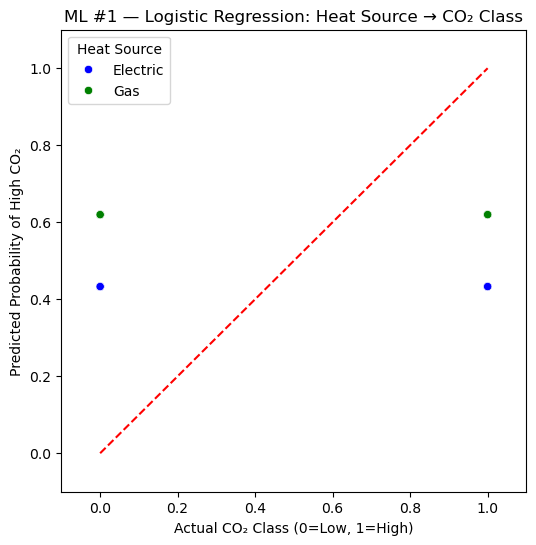

In [159]:
# 1. Create binary classes: High vs Low CO₂
median_CO2 = dfOvensML["CO2_Emissions"].median()
dfOvensML["HighCO2"] = (dfOvensML["CO2_Emissions"] > median_CO2).astype(int)

# Convert heat source to numeric
dfOvensML["HeatSourceEncoded"] = dfOvensML["Heat Source Fuel Type"].map({"Gas": 1, "Electric": 0})

# Drop rows with missing encoded values
dfOvensML = dfOvensML.dropna(subset=["HeatSourceEncoded"])


# 2. Train/Test Split
X = dfOvensML[["HeatSourceEncoded"]]
y = dfOvensML["HighCO2"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# 3. Baseline Calculation
majority_class = y_train.mode()[0]              # most common class
baseline_pred = np.full_like(y_test, majority_class)
baseline_accuracy = accuracy_score(y_test, baseline_pred)

# 4. Logistic Regression Model
clf = LogisticRegression()
clf.fit(X_train, y_train)

y_prob = clf.predict_proba(X_test)[:, 1]   # Probability of High CO₂
y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("===== ML #1 — CLASSIFICATION RESULTS =====")
print(f"Baseline Accuracy (Majority Class): {baseline_accuracy:.3f}")
print(f"Accuracy: {accuracy:.3f}")

# 5. Visualization — Probability vs Actual Class
plt.figure(figsize=(6,6))
sns.scatterplot(
    x=y_test,
    y=y_prob,
    hue=X_test["HeatSourceEncoded"].map({1: "Gas", 0: "Electric"}),
    palette=["blue", "green"]
)

# 45-degree reference line
plt.plot([0,1], [0,1], "--", color="red")

plt.xlabel("Actual CO₂ Class (0=Low, 1=High)")
plt.ylabel("Predicted Probability of High CO₂")
plt.title("ML #1 — Logistic Regression: Heat Source → CO₂ Class")
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.legend(title="Heat Source")
plt.show()

From this, it is clear that we need to have more features to classify whether or not an oven will produce low or high CO2.  

Looking at the dataset, there seems to be many features that could be used to predict CO2 emmissions. For this ML analysis, we are going to examine these features:
the type of heat source (gas or electric), oven classification, the size of the oven, the method of steam generation, the convection mode cooking energy efficiency, steam mode cooking energy efficiency, convection mode production capacity, and steam mode production capacity.

### Improvement of classification with more features!!!

===== ML #1 — Improved Classification =====
Baseline Accuracy (Majority Class): 0.470
Model Accuracy: 0.687


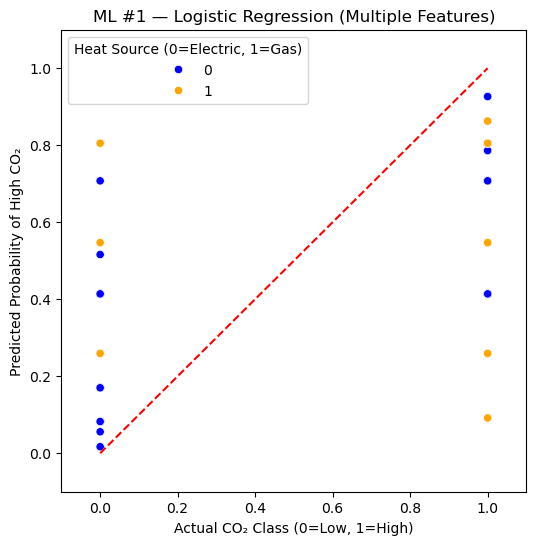

In [160]:
# 1. Create High vs Low CO₂ class
median_CO2 = dfOvensML["CO2_Emissions"].median()
dfOvensML["HighCO2"] = (dfOvensML["CO2_Emissions"] > median_CO2).astype(int)


# 2. Encode "Heat Source Fuel Type"
dfOvensML["HeatSourceEncoded"] = dfOvensML["Heat Source Fuel Type"].map({"Gas": 1, "Electric": 0})


# 3. Encode ALL categorical features
categorical_cols = [
    "Oven Classification",
    "Size",
    "Method of Steam Generation",
]

dfOvensML_encoded = dfOvensML.copy()

for col in categorical_cols:
    le = LabelEncoder()
    dfOvensML_encoded[col] = le.fit_transform(dfOvensML_encoded[col].astype(str))


# 4. Select MULTIPLE FEATURES
features = [
    "HeatSourceEncoded",
    "Oven Classification",
    "Size",
    "Method of Steam Generation"
]

df_model = dfOvensML_encoded[features + ["HighCO2"]].dropna()

X = df_model[features]
y = df_model["HighCO2"]

# 5. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# 6. Baseline Calculation
majority_class = y_train.mode()[0]              # most common class
baseline_pred = np.full_like(y_test, majority_class)
baseline_accuracy = accuracy_score(y_test, baseline_pred)


# 7. Logistic Regression Model
clf = LogisticRegression(max_iter=500)
clf.fit(X_train, y_train)

y_prob = clf.predict_proba(X_test)[:, 1]
y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("===== ML #1 — Improved Classification =====")
print(f"Baseline Accuracy (Majority Class): {baseline_accuracy:.3f}")
print(f"Model Accuracy: {accuracy:.3f}")

# 8. Visualization (color by heat source)
plt.figure(figsize=(6,6))
sns.scatterplot(
    x=y_test,
    y=y_prob,
    hue=X_test["HeatSourceEncoded"],
    palette=["blue", "orange"]
)

plt.plot([0,1], [0,1], "--", color="red")
plt.xlabel("Actual CO₂ Class (0=Low, 1=High)")
plt.ylabel("Predicted Probability of High CO₂")
plt.title("ML #1 — Logistic Regression (Multiple Features)")
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.legend(title="Heat Source (0=Electric, 1=Gas)")
plt.show()


Now, we are able to distinguish and predict what ovens will produce high Carbon Dioxide and low Carbon Dioxide based on certain features using Machine Learning with an accuracy of 68.7%. We also used a baseline from the features that is the most common (most common class) and found that our model did way better than that which means our model learned enough data to determine if a certain oven will emit high or low CO2 based on its features.  

Let's just rewind and summarize what we actually accomplished here. Our goal was to classify whether or not qualitative characteristics could determine and classify an oven producing high or low carbon dioxide. What did we do? Well, first we experimented with just one feature (the type of heat source whether it be electric or gas) and determined that this was not at all a good meaasure of determining whether an oven can produce either high or low carbon dioxide. Even though it did way better than the baseline, there are other features that could be added onto this that can make the percentage even higher. So in the second ML Analysis, we started to implement more features into our model where we found that more features increase the accuracy of our model! Doing so made our accuracy even greater to correctly identify which models could and could not give you high CO2. 



In the next Machine Learning Analysis, we are going to make a regression model using these features to determine a function that can accurately determine how much carbon dioxide will be emitted based on an oven with inputs as the Heat Source, the input rate, the convection mode cooking energy efficiency, the steam mode cooking energy efficiency, the convection mode production capacity, and the steam mode production capacity. 

### Machine Learning Analysis #2: Predicting Oven Carbon Dioxide Emissions with Features

===== ML #2 — REGRESSION RESULTS =====
Baseline MSE: 0.000092
Baseline R² Score: -0.126023
Model MSE: 0.000033
Model R² Score: 0.602264

Feature Coefficients:
  HeatSourceEncoded: 10.387342
  Oven Classification: -21.162393
  Size: 2.367043
  Baking Production Capacity (lbs/hr): 0.258500

===== Linear Regression Equation =====
InputRate_kW = 24.652274 + (10.387342)*HeatSourceEncoded + (-21.162393)*Oven Classification + (2.367043)*Size + (0.258500)*Baking Production Capacity (lbs/hr)

===== CO₂ Emissions Equation (metric tons) =====
CO2 = 0.009713 + (0.004093)*HeatSourceEncoded + (-0.008338)*Oven Classification + (0.000933)*Size + (0.000102)*Baking Production Capacity (lbs/hr)


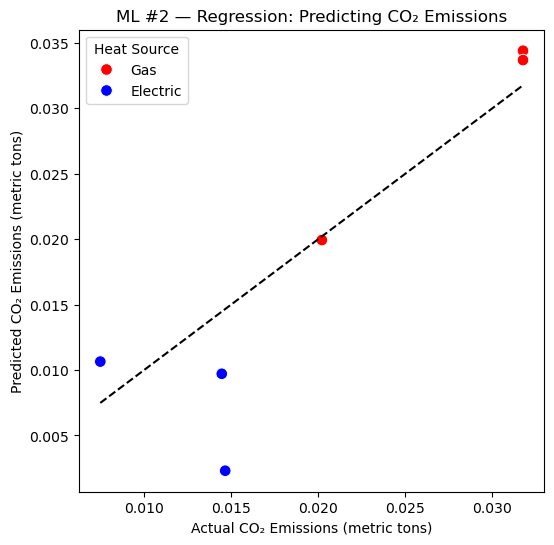

In [161]:
# ML #2 — Predict Carbon Dioxide Emissions 

df2 = dfOvensML.copy()


# 1. Select meaningful features
features = [
    "HeatSourceEncoded",
    "Oven Classification",
    "Size",
    "Baking Production Capacity (lbs/hr)"
]

target = "InputRate_kW"  # Predict energy input → later convert to CO₂



# 2. Encode categorical features
cat_cols = ["Oven Classification", "Size"]

le = LabelEncoder()

for col in cat_cols:
    df2[col] = le.fit_transform(df2[col].astype(str))



# 3. Drop rows missing any feature or target
df2 = df2.dropna(subset=features + [target])

X = df2[features]
y = df2[target]



# 4. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# 5. Baseline: Predict mean InputRate_kW
baseline_pred = np.full_like(y_test, y_train.mean())
baseline_mse = mean_squared_error(y_test * 3.94e-4, baseline_pred * 3.94e-4)
# Convert to CO₂ (like your ML predictions)
baseline_pred_CO2 = baseline_pred * 3.94e-4
y_test_CO2 = y_test * 3.94e-4
# Baseline R²
baseline_r2 = r2_score(y_test_CO2, baseline_pred_CO2)


# 6. Linear Regression Model
reg = LinearRegression()
reg.fit(X_train, y_train)

y_pred_input = reg.predict(X_test)


# ------------------------------------------------------
# 7. Convert InputRate_kW → CO₂ (metric tons)
#    EPA conversion factor:
#    3.94e-4 metric tons CO₂ per kWh
# ------------------------------------------------------
y_test_CO2 = y_test * 3.94e-4
y_pred_CO2 = y_pred_input * 3.94e-4



# 8. Evaluate
mse = mean_squared_error(y_test_CO2, y_pred_CO2)
r2 = r2_score(y_test_CO2, y_pred_CO2)

print("===== ML #2 — REGRESSION RESULTS =====")
print(f"Baseline MSE: {baseline_mse:.6f}")
print(f"Baseline R² Score: {baseline_r2:.6f}")
print(f"Model MSE: {mse:.6f}")
print(f"Model R² Score: {r2:.6f}\n")

print("Feature Coefficients:")
for name, coef in zip(features, reg.coef_):
    print(f"  {name}: {coef:.6f}")

# -----------------------------------------
# Print the Regression Equation
# CO₂ = b0 + b1*x1 + b2*x2 + ...
# -----------------------------------------

intercept = reg.intercept_
coeffs = reg.coef_

print("\n===== Linear Regression Equation =====")
equation = f"InputRate_kW = {intercept:.6f}"

for name, coef in zip(features, coeffs):
    equation += f" + ({coef:.6f})*{name}"

print(equation)

# Convert entire equation to CO₂ emissions
print("\n===== CO₂ Emissions Equation (metric tons) =====")
equation_CO2 = f"CO2 = {intercept*3.94e-4:.6f}"

for name, coef in zip(features, coeffs):
    equation_CO2 += f" + ({coef*3.94e-4:.6f})*{name}"

print(equation_CO2)



# 8. Plot Predicted vs Actual CO₂ Emissions
heat_labels = {0: "Electric", 1: "Gas"}

plt.figure(figsize=(6,6))
sns.scatterplot(
    x=y_test_CO2,
    y=y_pred_CO2,
    hue=X_test["HeatSourceEncoded"].map(heat_labels),
    palette={"Electric": "blue", "Gas": "red"},
    s=70
)

# 45-degree line
plt.plot([y_test_CO2.min(), y_test_CO2.max()],
         [y_test_CO2.min(), y_test_CO2.max()],
         "--", color="black")

plt.xlabel("Actual CO₂ Emissions (metric tons)")
plt.ylabel("Predicted CO₂ Emissions (metric tons)")
plt.title("ML #2 — Regression: Predicting CO₂ Emissions")
plt.legend(title="Heat Source")
plt.show()


From this, we have successfully created a regression line that can be used to predict how much Carbon Dioxide an oven emits as long as we have the oven heat source classification, oven classification, size, and baking production capacity. We are able to do this with the equation that we have from the regression line. Furthermore, our ML analysis is correct as our R^2 is correct (close to 1 and positive) with our MSE being really low. Not only this, we have used a baseline to compare this as well and determined that model predicted CO2 emissions more better than the baseline! 

What does this tell us?  
This tells us that general CO2 emission levels can be predicted using qualititative features and exact and more precice CO2 emission levels can be predicted using quantitave features. 

### Machine Learning Analysis #3: Regression Model to Predict Ceiling Fan CO₂ Emissions

Author: Shri

===== CEILING FAN CO₂ EMISSIONS REGRESSION =====
Baseline MSE: 0.00021475
Baseline R² Score: -0.160058
Model MSE: 0.00005535
Model R² Score: 0.700981

Feature Coefficients:
  Ceiling Fan Efficiency (CFM/W): -0.0001900436
  Blade Span (Diameter) (in.): -0.0007254028
  Airflow (CFM): 0.0000088343
  ProductTypeEncoded: -0.0003258764

===== Regression Equation =====
CO₂ = 0.061873 + (-0.000190)*Ceiling Fan Efficiency (CFM/W) + (-0.000725)*Blade Span (Diameter) (in.) + (0.000009)*Airflow (CFM) + (-0.000326)*ProductTypeEncoded


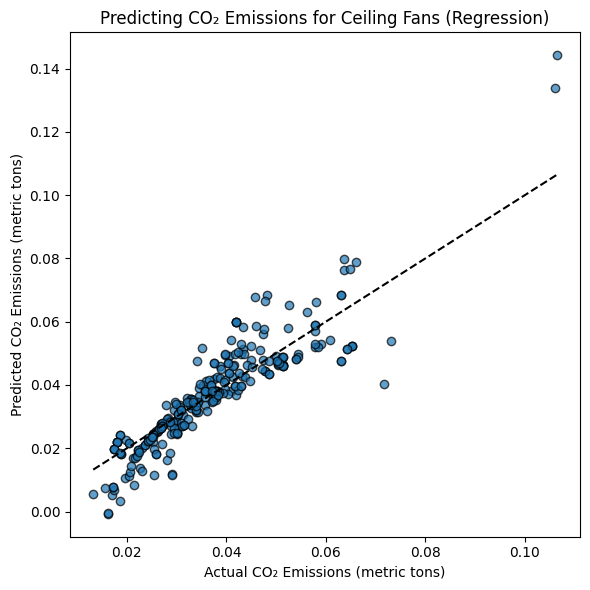

In [4]:
# Load Fan Dataset
df_fans = pd.read_csv("CeilingFans_Cleaned.csv")

# Select required columns (needed to calculate features & target)
cols_needed = [
    "Ceiling Fan Efficiency (CFM/W)",
    "Fan Power Consumption-High Speed (W)",
    "Blade Span (Diameter) (in.)",
    "Product Type"
]

df = df_fans.dropna(subset=cols_needed).copy()

# Convert numeric fields
num_cols = [
    "Ceiling Fan Efficiency (CFM/W)",
    "Fan Power Consumption-High Speed (W)",
    "Blade Span (Diameter) (in.)"
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(",", ""), errors="coerce")

df = df.dropna(subset=cols_needed)

# Create Airflow Feature (useful + independent of target)
df["Airflow (CFM)"] = df["Ceiling Fan Efficiency (CFM/W)"] * df["Fan Power Consumption-High Speed (W)"]

# Target: Estimated CO2 Emissions
hours_per_day = 8
yearly_kWh = (df["Fan Power Consumption-High Speed (W)"] * hours_per_day * 365) / 1000
df["CO2 Emissions (metric tons)"] = yearly_kWh * 3.94e-4   # EPA conversion factor

# Encode categorical feature
le = LabelEncoder()
df["ProductTypeEncoded"] = le.fit_transform(df["Product Type"].astype(str))

# Select features WITHOUT wattage to avoid leakage
features = [
    "Ceiling Fan Efficiency (CFM/W)",
    "Blade Span (Diameter) (in.)",
    "Airflow (CFM)",
    "ProductTypeEncoded"
]

target = "CO2 Emissions (metric tons)"

X = df[features]
y = df[target]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Baseline (Predict Mean)
baseline_pred = np.full_like(y_test, y_train.mean())
baseline_mse = mean_squared_error(y_test, baseline_pred)
baseline_r2 = r2_score(y_test, baseline_pred)

# Train Regression Model
reg = LinearRegression()
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)

# Evaluation Metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("===== CEILING FAN CO₂ EMISSIONS REGRESSION =====")
print(f"Baseline MSE: {baseline_mse:.8f}")
print(f"Baseline R² Score: {baseline_r2:.6f}")
print(f"Model MSE: {mse:.8f}")
print(f"Model R² Score: {r2:.6f}\n")

print("Feature Coefficients:")
for name, coef in zip(features, reg.coef_):
    print(f"  {name}: {coef:.10f}")

intercept = reg.intercept_
print("\n===== Regression Equation =====")
equation = f"CO₂ = {intercept:.6f}"
for name, coef in zip(features, reg.coef_):
    equation += f" + ({coef:.6f})*{name}"
print(equation)

# Scatter Plot (Actual vs Predicted)
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.7, edgecolors='k')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "--", color="black")
plt.xlabel("Actual CO₂ Emissions (metric tons)")
plt.ylabel("Predicted CO₂ Emissions (metric tons)")
plt.title("Predicting CO₂ Emissions for Ceiling Fans (Regression)")
plt.tight_layout()
plt.show()


From this analysis, we built a regression model that predicts the CO₂ emissions of a ceiling fan using measurable features such as its efficiency (CFM/W), blade span, airflow, and product category. By using the regression equation we obtained, we can now estimate the carbon impact of any fan as long as these characteristics are known. Compared to the baseline, our model performs much better because it produces a lower MSE and a significantly higher R squared value of 0.70. This means the model captures real variation in the data instead of just predicting an average, making it a meaningful and reliable estimator.

What this tells us:
This result shows that ceiling fan emissions are not random and that they can be estimated using both design-based factors (like blade span and product type) and performance-based measures (such as efficiency and airflow). Fans with higher efficiency and wider blades tend to emit less CO₂, while greater airflow and power usage increase emissions.  

In short, fan design and performance together influence a fan’s environmental footprint, and this relationship can be predicted using machine learning.

### Power Consumption vs CO₂ Emissions Scatterplot

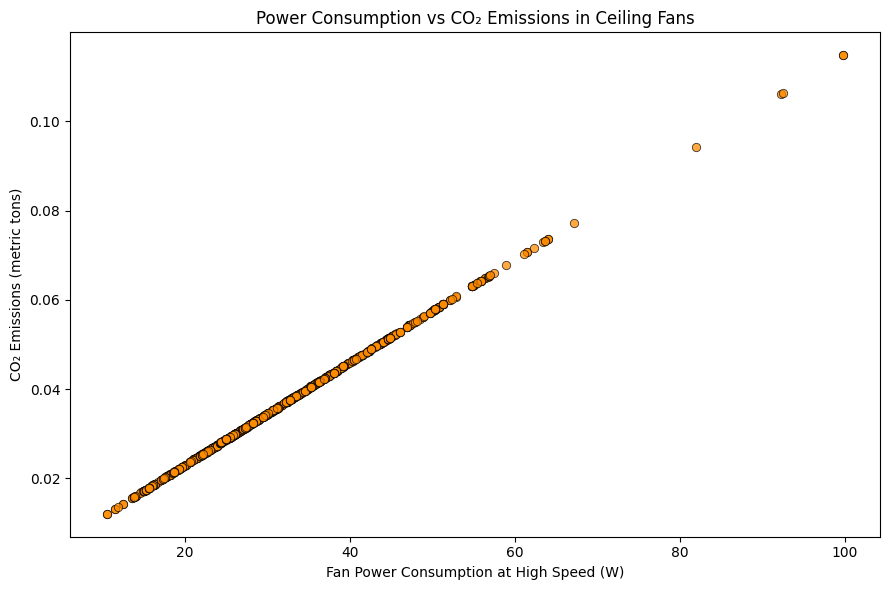

In [5]:
# Remove unrealistic outliers (industrial fans)
df_filtered = df[df["Fan Power Consumption-High Speed (W)"] < 500]

plt.figure(figsize=(9,6))
plt.scatter(
    df_filtered["Fan Power Consumption-High Speed (W)"],
    df_filtered["CO2 Emissions (metric tons)"],
    alpha=0.75, edgecolor='black', linewidth=0.6, color="#FF8C00"
)

plt.xlabel("Fan Power Consumption at High Speed (W)")
plt.ylabel("CO₂ Emissions (metric tons)")
plt.title("Power Consumption vs CO₂ Emissions in Ceiling Fans")
plt.tight_layout()
plt.show()


After removing one outlier (a 4500W fan), the plot clearly shows a strong linear trend between power consumption and CO₂ emissions. This makes sense because household ceiling fans use electricity at a fairly constant daily rate, so higher power draw directly means more yearly energy use and therefore higher carbon emissions. This visualization supports our regression model and confirms that power rating is one of the most important predictors of a fan’s carbon impact.

### Machine Learning Analysis #4: Regression Model to Predict Annual Energy Use
#### Author: Shounak Sawant

===== ML #4 — CLASSIFICATION RESULTS (Air Conditioners) =====
Baseline Accuracy (Majority Class): 0.531
Model Accuracy: 0.688


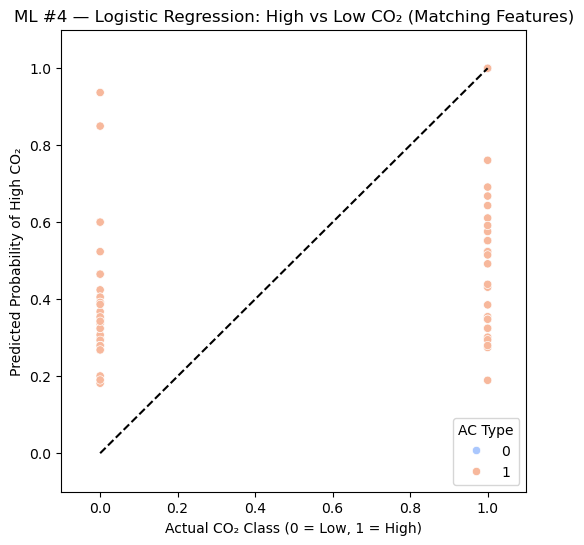

In [163]:
# ML #4 — CLASSIFICATION: Predict High vs Low CO₂ Air Conditioners

df_AC1 = pd.read_csv("AirConditioners_Cleaned.csv")

# -----------------------------------------------------------
# 1. Compute CO₂ emissions 
# -----------------------------------------------------------

df_AC1["CO2_Emissions"] = df_AC1["Annual Energy Use (kWh/yr)"] * 3.94e-4

# Median split -> balanced classification
median_CO2 = df_AC1["CO2_Emissions"].median()
df_AC1["HighCO2"] = (df_AC1["CO2_Emissions"] > median_CO2).astype(int)

# -----------------------------------------------------------
# 2. Features
# -----------------------------------------------------------

features = [
    "Brand Name",
    "Type",
    "Heating Mode",
    "Height (inches)",
    "Width (inches)",
    "Depth (inches)",
    "Weight (lbs)",
    "Voltage (volts)"
]

cat_cols = ["Brand Name", "Type", "Heating Mode"]

# Encode categorical features
le = LabelEncoder()
for col in cat_cols:
    df_AC1[col] = le.fit_transform(df_AC1[col].astype(str))

# Drop rows missing any required values
df_AC1 = df_AC1.dropna(subset=features + ["HighCO2"])

# Input matrix + target
X = df_AC1[features]
y = df_AC1["HighCO2"]

# -----------------------------------------------------------
# 3. Train/Test Split
# -----------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# -----------------------------------------------------------
# 4. Baseline: predict most common class
# -----------------------------------------------------------

majority_class = y_train.mode()[0]
baseline_pred = np.full_like(y_test, majority_class)
baseline_accuracy = accuracy_score(y_test, baseline_pred)

# -----------------------------------------------------------
# 5. Logistic Regression Model
# -----------------------------------------------------------

clf = LogisticRegression(max_iter=500)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)

print("===== ML #4 — CLASSIFICATION RESULTS (Air Conditioners) =====")
print(f"Baseline Accuracy (Majority Class): {baseline_accuracy:.3f}")
print(f"Model Accuracy: {accuracy:.3f}")

# -----------------------------------------------------------
# 6. Visualization
# -----------------------------------------------------------

plt.figure(figsize=(6,6))
sns.scatterplot(
    x=y_test,
    y=y_prob,
    hue=X_test["Type"],
    palette="coolwarm"
)

plt.plot([0,1], [0,1], "--", color="black")

plt.xlabel("Actual CO₂ Class (0 = Low, 1 = High)")
plt.ylabel("Predicted Probability of High CO₂")
plt.title("ML #4 — Logistic Regression: High vs Low CO₂ (Matching Features)")
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.legend(title="AC Type")
plt.show()


===== ML #4 — REGRESSION RESULTS for Air Conditioners =====
Baseline MSE: 0.002616
Baseline R² Score: -0.017428
Model MSE: 0.001657
Model R² Score: 0.355471

Feature Coefficients:
  Brand Name: -0.486622
  Type: 44.536982
  Heating Mode: -61.731509
  Height (inches): 14.773760
  Width (inches): -2.388743
  Depth (inches): -15.857209
  Weight (lbs): 3.599022
  Voltage (volts): 2.168536

===== Linear Regression Equation (Energy Use) =====
AnnualEnergyUse_kWh = 204.639319 + (-0.486622)*Brand Name + (44.536982)*Type + (-61.731509)*Heating Mode + (14.773760)*Height (inches) + (-2.388743)*Width (inches) + (-15.857209)*Depth (inches) + (3.599022)*Weight (lbs) + (2.168536)*Voltage (volts)

===== CO₂ Emissions Equation (metric tons) =====
CO2_metric_tons = 0.080628 + (-0.000192)*Brand Name + (0.017548)*Type + (-0.024322)*Heating Mode + (0.005821)*Height (inches) + (-0.000941)*Width (inches) + (-0.006248)*Depth (inches) + (0.001418)*Weight (lbs) + (0.000854)*Voltage (volts)


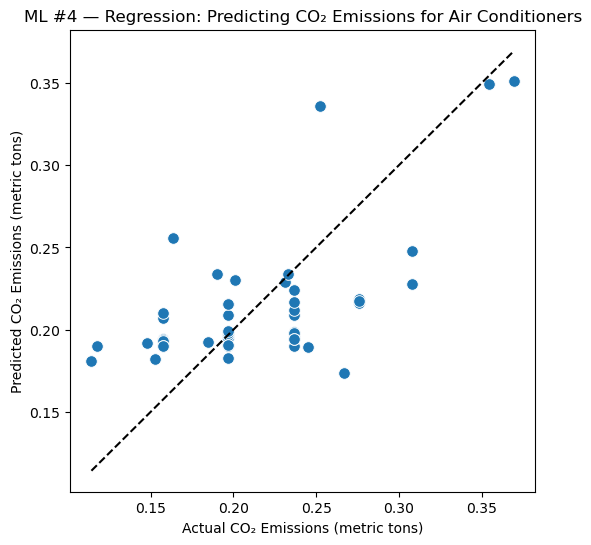

In [164]:
df_AC2 = pd.read_csv("AirConditioners_Cleaned.csv")

# 1. Features 
features = [
    "Brand Name",
    "Type",
    "Heating Mode",        
    "Height (inches)",
    "Width (inches)",
    "Depth (inches)",
    "Weight (lbs)",
    "Voltage (volts)"
]

target = "Annual Energy Use (kWh/yr)"

# 2. Encode categorical features
cat_cols = ["Brand Name", "Type", "Heating Mode"]  
le = LabelEncoder()

for col in cat_cols:
    df_AC2[col] = le.fit_transform(df_AC2[col].astype(str))

# 3. Drop rows missing any feature or target
df_AC2 = df_AC2.dropna(subset=features + [target])

X = df_AC2[features]
y = df_AC2[target]

# 4. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# 5. Baseline: Predict mean Annual Energy Use
baseline_pred = np.full_like(y_test, y_train.mean())

# Convert to CO₂
y_test_CO2 = y_test * 3.94e-4
baseline_pred_CO2 = baseline_pred * 3.94e-4

# Baseline metrics
baseline_mse = mean_squared_error(y_test_CO2, baseline_pred_CO2)
baseline_r2 = r2_score(y_test_CO2, baseline_pred_CO2)

# 6. Linear Regression Model
reg = LinearRegression()
reg.fit(X_train, y_train)

y_pred_input = reg.predict(X_test)

# 7. Convert predicted Annual Energy → CO₂
y_pred_CO2 = y_pred_input * 3.94e-4

# 8. Evaluate
mse = mean_squared_error(y_test_CO2, y_pred_CO2)
r2 = r2_score(y_test_CO2, y_pred_CO2)

print("===== ML #4 — REGRESSION RESULTS for Air Conditioners =====")
print(f"Baseline MSE: {baseline_mse:.6f}")
print(f"Baseline R² Score: {baseline_r2:.6f}")
print(f"Model MSE: {mse:.6f}")
print(f"Model R² Score: {r2:.6f}\n")

print("Feature Coefficients:")
for name, coef in zip(features, reg.coef_):
    print(f"  {name}: {coef:.6f}")

# Print Regression Equation (Energy Use)
intercept = reg.intercept_
coeffs = reg.coef_

print("\n===== Linear Regression Equation (Energy Use) =====")
equation = f"AnnualEnergyUse_kWh = {intercept:.6f}"
for name, coef in zip(features, coeffs):
    equation += f" + ({coef:.6f})*{name}"
print(equation)

# Convert entire equation to CO₂ emissions
print("\n===== CO₂ Emissions Equation (metric tons) =====")
equation_CO2 = f"CO2_metric_tons = {intercept*3.94e-4:.6f}"
for name, coef in zip(features, coeffs):
    equation_CO2 += f" + ({coef*3.94e-4:.6f})*{name}"
print(equation_CO2)

# 9. Plot Predicted vs Actual CO₂ Emissions
plt.figure(figsize=(6, 6))
sns.scatterplot(
    x=y_test_CO2,
    y=y_pred_CO2,
    s=70
)

# plot
plt.plot(
    [y_test_CO2.min(), y_test_CO2.max()],
    [y_test_CO2.min(), y_test_CO2.max()],
    "--",
    color="black"
)

plt.xlabel("Actual CO₂ Emissions (metric tons)")
plt.ylabel("Predicted CO₂ Emissions (metric tons)")
plt.title("ML #4 — Regression: Predicting CO₂ Emissions for Air Conditioners")
plt.show()


From this, we have created a regression line that can be used to predict how much Carbon Dioxide an air conditioner emits as long as we have the brand name, AC type, heating mode, dimensions (height, width, depth), weight, and voltage. We are able to do this with the equation that we have from the regression line. Our ML analysis shows moderate performance as our R² is 0.355471 with our MSE being 0.001657. We have used a baseline to compare this as well and determined that our model predicted CO₂ emissions significantly better than the baseline.


What does this tell us? 

This tells us that general CO2 emission levels can be predicted using qualitative features and exact and more precise CO2 emission levels can be predicted using quantitative features.

### Machine Learning Analysis #5: Regression Model to Predict Television Annual Energy Consumption
#### Author: Rahee Chauhan

===== ML #5 — CLASSIFICATION RESULTS (Televisions) =====
Baseline Accuracy: 0.486
Model Accuracy: 0.784


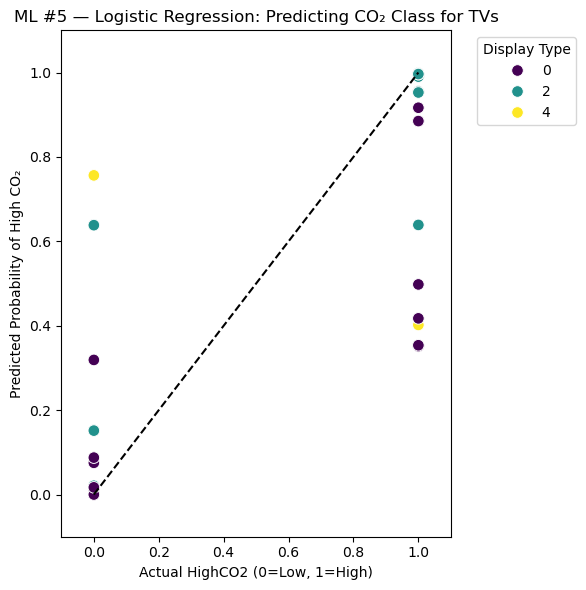

In [165]:
# ML #5 — CLASSIFICATION: Predict High vs Low CO₂ for Televisions

df_TV1 = pd.read_csv("Televisions_Cleaned.csv")

# -----------------------------------------------------------
# 1. Compute CO₂ emissions 
# -----------------------------------------------------------

df_TV1["CO2_Emissions"] = df_TV1["Reported Annual Energy Consumption (kWh)"] * 3.94e-4
median_CO2 = df_TV1["CO2_Emissions"].median()
df_TV1["HighCO2"] = (df_TV1["CO2_Emissions"] > median_CO2).astype(int)

# -----------------------------------------------------------
# 2. Features
# -----------------------------------------------------------

features = [
    "Brand Name",
    "Display Type",
    "Backlight Technology Type",
    "Resolution Format",
    "Diagonal Viewable Screen Size (in.)",
    "Screen Area (sq. in.)",
    "Native Horizontal Resolution (pixels)",
    "Native Vertical Resolution (pixels)"
]

cat_cols = [
    "Brand Name",
    "Display Type",
    "Backlight Technology Type",
    "Resolution Format"
]

# Label encode categorical features
le = LabelEncoder()
for col in cat_cols:
    df_TV1[col] = le.fit_transform(df_TV1[col].astype(str))

# Drop missing rows
df_TV1 = df_TV1.dropna(subset=features + ["HighCO2"])

X = df_TV1[features]
y = df_TV1["HighCO2"]

# -----------------------------------------------------------
# 3. Train/Test Split
# -----------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# -----------------------------------------------------------
# 4. Baseline (Majority Class)
# -----------------------------------------------------------

majority_class = y_train.mode()[0]
baseline_pred = np.full_like(y_test, majority_class)
baseline_accuracy = accuracy_score(y_test, baseline_pred)

# -----------------------------------------------------------
# 5. Logistic Regression Model
# -----------------------------------------------------------

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)

print("===== ML #5 — CLASSIFICATION RESULTS (Televisions) =====")
print(f"Baseline Accuracy: {baseline_accuracy:.3f}")
print(f"Model Accuracy: {accuracy:.3f}")

# -----------------------------------------------------------
# 6. Visualization
# -----------------------------------------------------------

plt.figure(figsize=(6,6))
sns.scatterplot(
    x=y_test,
    y=y_prob,
    hue=X_test["Display Type"],
    palette="viridis",
    s=70
)

plt.plot([0,1], [0,1], "--", color="black")
plt.xlabel("Actual HighCO2 (0=Low, 1=High)")
plt.ylabel("Predicted Probability of High CO₂")
plt.title("ML #5 — Logistic Regression: Predicting CO₂ Class for TVs")
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.legend(title="Display Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


===== ML #5 — REGRESSION RESULTS (Televisions) =====
Baseline MSE: 0.001089
Baseline R² Score: -0.011934
Model MSE: 0.000147
Model R² Score: 0.863462

Feature Coefficients:
  Brand Name: 2.743492
  Display Type: 12.693293
  Backlight Technology Type: 15.266898
  Resolution Format: -1.437921
  Diagonal Viewable Screen Size (in.): -0.373251
  Screen Area (sq. in.): 0.094081
  Native Horizontal Resolution (pixels): 0.000188
  Native Vertical Resolution (pixels): 0.003942

===== Linear Regression Equation (Energy Use) =====
AnnualEnergyUse_kWh = 10.230286 + (2.743492)*Brand Name + (12.693293)*Display Type + (15.266898)*Backlight Technology Type + (-1.437921)*Resolution Format + (-0.373251)*Diagonal Viewable Screen Size (in.) + (0.094081)*Screen Area (sq. in.) + (0.000188)*Native Horizontal Resolution (pixels) + (0.003942)*Native Vertical Resolution (pixels)

===== CO₂ Emissions Equation (metric tons) =====
CO2_metric_tons = 0.004031 + (0.001081)*Brand Name + (0.005001)*Display Type + (0.00

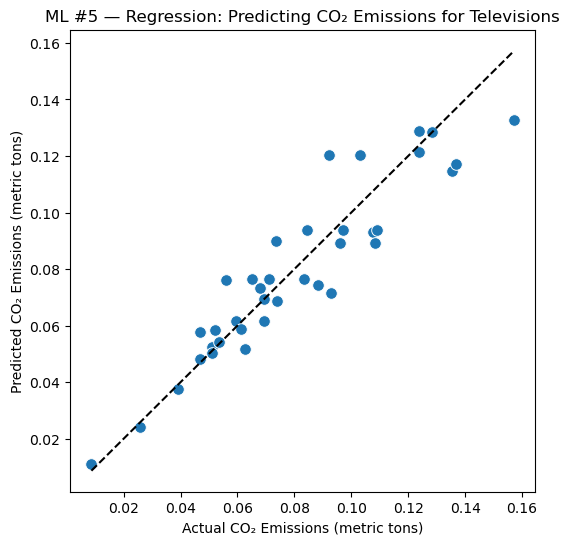

In [166]:
df_TV = pd.read_csv('Televisions_Cleaned.csv')
df2 = df_TV.copy()

features = [
    "Brand Name",
    "Display Type",
    "Backlight Technology Type",
    "Resolution Format",
    "Diagonal Viewable Screen Size (in.)",
    "Screen Area (sq. in.)",
    "Native Horizontal Resolution (pixels)",
    "Native Vertical Resolution (pixels)"
]

target = "Reported Annual Energy Consumption (kWh)"  

# 2. Encode categorical features
cat_cols = ["Brand Name", "Display Type", "Backlight Technology Type", "Resolution Format"]
le = LabelEncoder()

for col in cat_cols:
    df2[col] = le.fit_transform(df2[col].astype(str))

# 3. Drop rows missing any feature 
df2 = df2.dropna(subset=features + [target])

X = df2[features]
y = df2[target]

# 4. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# 5. Baseline: predict mean annual energy use
baseline_pred = np.full_like(y_test, y_train.mean())

y_test_CO2 = y_test * 3.94e-4
baseline_pred_CO2 = baseline_pred * 3.94e-4

baseline_mse = mean_squared_error(y_test_CO2, baseline_pred_CO2)
baseline_r2 = r2_score(y_test_CO2, baseline_pred_CO2)

# 6. Linear Regression Model
reg = LinearRegression()
reg.fit(X_train, y_train)

y_pred_input = reg.predict(X_test)
y_pred_CO2 = y_pred_input * 3.94e-4

# 7. Evaluate model
mse = mean_squared_error(y_test_CO2, y_pred_CO2)
r2 = r2_score(y_test_CO2, y_pred_CO2)

print("===== ML #5 — REGRESSION RESULTS (Televisions) =====")
print(f"Baseline MSE: {baseline_mse:.6f}")
print(f"Baseline R² Score: {baseline_r2:.6f}")
print(f"Model MSE: {mse:.6f}")
print(f"Model R² Score: {r2:.6f}\n")

print("Feature Coefficients:")
for name, coef in zip(features, reg.coef_):
    print(f"  {name}: {coef:.6f}")

# 8. Regression Equation
intercept = reg.intercept_
coeffs = reg.coef_

print("\n===== Linear Regression Equation (Energy Use) =====")
equation = f"AnnualEnergyUse_kWh = {intercept:.6f}"
for name, coef in zip(features, coeffs):
    equation += f" + ({coef:.6f})*{name}"
print(equation)

# 9. CO₂ Emissions Equation
print("\n===== CO₂ Emissions Equation (metric tons) =====")
equation_CO2 = f"CO2_metric_tons = {intercept*3.94e-4:.6f}"
for name, coef in zip(features, coeffs):
    equation_CO2 += f" + ({coef*3.94e-4:.6f})*{name}"
print(equation_CO2)

# 10. Plot Predicted vs Actual CO₂ Emissions
plt.figure(figsize=(6, 6))
sns.scatterplot(
    x=y_test_CO2,
    y=y_pred_CO2,
    s=70
)

# plot
plt.plot(
    [y_test_CO2.min(), y_test_CO2.max()],
    [y_test_CO2.min(), y_test_CO2.max()],
    "--",
    color="black"
)

plt.xlabel("Actual CO₂ Emissions (metric tons)")
plt.ylabel("Predicted CO₂ Emissions (metric tons)")
plt.title("ML #5 — Regression: Predicting CO₂ Emissions for Televisions")
plt.show()

From this, we have created a regression line that can be used to predict how much Carbon Dioxide a television emits as long as we have the brand name, display type, backlight technology type, resolution format, diagonal viewable screen size, screen area, native horizontal resolution, and native vertical resolution. We are able to do this with the equation that we have from the regression line. Our ML analysis is very good as our R² is very high (0.863462) with our MSE being very low (0.000147). We also used a baseline to compare this as well and determined that our model predicted CO₂ emissions significantly better than the baseline.

What does this tell us? 

This tells us that general CO₂ emission levels can be predicted using qualitative features and exact and more precise CO₂ emission levels can be predicted using quantitative features.

### Machine Learning Analysis #6: Refrigerators ML 
#### Author: Karthik Kesavarapu
In this section, we are going to be analyzing if the amount of carbon dioxide omissions for refrigerators can be predicted using quantitative and qualitative features. 

In [167]:
# 1. Load Data
dfRefrigeratorML = pd.read_csv('Refrigerators_Cleaned.csv')
print(dfRefrigeratorML.info())
print(dfRefrigeratorML.columns.tolist())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 604 entries, 0 to 603
Data columns (total 32 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   ENERGY STAR Unique ID                                   604 non-null    int64  
 1   Brand Name                                              603 non-null    object 
 2   Model Number                                            604 non-null    object 
 3   Additional Model Information                            604 non-null    object 
 4   UPC                                                     375 non-null    object 
 5   Type                                                    602 non-null    object 
 6   Product Class                                           604 non-null    object 
 7   Defrost Type                                            593 non-null    object 
 8   Compact                                 

Again, this was just to remind the readers of this notebook what data is stored in the cleaned refrigerators dataset. Time to actually do some ML analysis!

===== Refrigerator ML — High vs Low CO₂ Classification =====
Features Used: ['Type', 'Defrost Type', 'Ice Maker', 'Capacity (Total Volume) (ft3)', 'Adjusted Volume (ft3)']
Baseline Accuracy (Majority Class): 0.570
Model Accuracy: 0.987
Median CO₂ Threshold: 140.46 kg/year


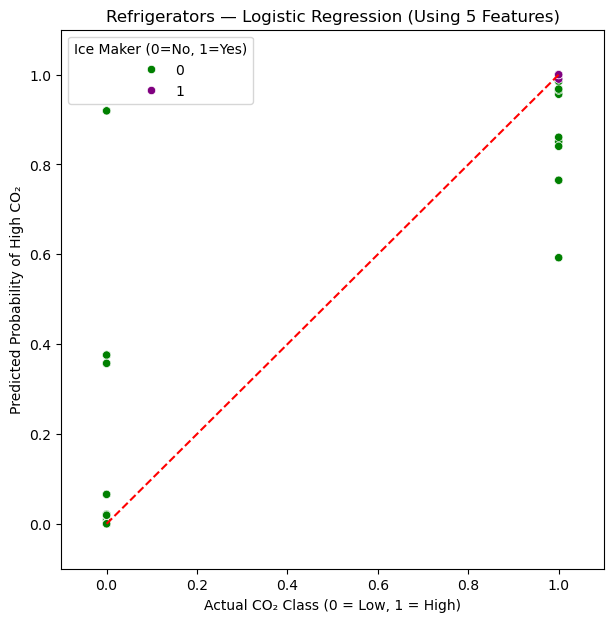

In [168]:
# ============================================
# 2. Compute CO₂ Emissions (kg CO₂ per year)
# ============================================
dfRefrigeratorML["CO2_Emissions"] = (
    dfRefrigeratorML["Annual Energy Use (kWh/yr)"] * 0.388
)

# ============================================
# 3. Create High vs Low CO₂ Label
# ============================================
median_CO2 = dfRefrigeratorML["CO2_Emissions"].median()
dfRefrigeratorML["HighCO2"] = (
    dfRefrigeratorML["CO2_Emissions"] > median_CO2
).astype(int)

# ============================================
# 4. Encode Categorical Features
# ============================================
categorical_cols = ["Type", "Defrost Type"]

df_encoded = dfRefrigeratorML.copy()

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# ============================================
# 5. Select Your Features
# ============================================
features = [
    "Type",
    "Defrost Type",
    "Ice Maker",
    "Capacity (Total Volume) (ft3)",
    "Adjusted Volume (ft3)"
]

df_model = df_encoded[features + ["HighCO2"]].dropna()

X = df_model[features]
y = df_model["HighCO2"]

# ============================================
# 6. Train/Test Split
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# ============================================
# 7. Baseline Accuracy
# ============================================
majority_class = y_train.mode()[0]
baseline_pred = np.full_like(y_test, majority_class)
baseline_accuracy = accuracy_score(y_test, baseline_pred)

# ============================================
# 8. Logistic Regression Model
# ============================================
clf = LogisticRegression(max_iter=500)
clf.fit(X_train, y_train)

y_prob = clf.predict_proba(X_test)[:, 1]
y_pred = clf.predict(X_test)

model_accuracy = accuracy_score(y_test, y_pred)

print("===== Refrigerator ML — High vs Low CO₂ Classification =====")
print(f"Features Used: {features}")
print(f"Baseline Accuracy (Majority Class): {baseline_accuracy:.3f}")
print(f"Model Accuracy: {model_accuracy:.3f}")
print(f"Median CO₂ Threshold: {median_CO2:.2f} kg/year")

# ============================================
# 9. Visualization
# ============================================
plt.figure(figsize=(7,7))
sns.scatterplot(
    x=y_test,
    y=y_prob,
    hue=X_test["Ice Maker"],   # color by Ice Maker (0/1)
    palette=["green", "purple"]
)

plt.plot([0,1], [0,1], "--", color="red")
plt.xlabel("Actual CO₂ Class (0 = Low, 1 = High)")
plt.ylabel("Predicted Probability of High CO₂")
plt.title("Refrigerators — Logistic Regression (Using 5 Features)")
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.legend(title="Ice Maker (0=No, 1=Yes)")
plt.show()

For analyzing how to predict the overall carbon dioxide emissions from the Refrigerators dataset, these five quantitative and qualitative features really stood out. The five features that were used was type, defrost type, ice maker, capacity (ft^3) and adjust volume (ft^3). The type shows the structural configuration so what type of freezer is going to be on the refrigerator and which way. This matteres a lot because this affects how compact the fridge will actually be. The next feature that was used was defrost type, and there were two main types of defrost types: automatic and manual. This is very similar to the gas and electric encoded situation in the ovens as there might be a correlation with carbon dioxide emissions with these two features. Another similar encoded situation was with the ice maker and this heavily influenced the model's accuracy in predicting whether a refrigerator will produce high or low carbon dioxide. The last two are quantitative variables that just help the model's accuracy in determining how much carbon dioxide is being produced simply because they talk about the overall size of the refrigerators. 

#### ML #7: Regression Line to Quanitify The Classification in ML #6

===== ML #7 — REGRESSION RESULTS (Refrigerators) =====
Baseline MSE: 3621.860856
Baseline R² Score: -0.012581
Model MSE: 212.417234
Model R² Score: 0.940614

Feature Coefficients:
  Type: -5.575351
  Defrost Type: -17.960236
  Ice Maker: 32.512177
  Capacity (Total Volume) (ft3): -7.923303
  Adjusted Volume (ft3): 9.778916

===== CO₂ Emissions Equation (metric tons/yr) =====
CO2_mt = 0.110021 + (-0.005575)*Type + (-0.017960)*Defrost Type + (0.032512)*Ice Maker + (-0.007923)*Capacity (Total Volume) (ft3) + (0.009779)*Adjusted Volume (ft3)


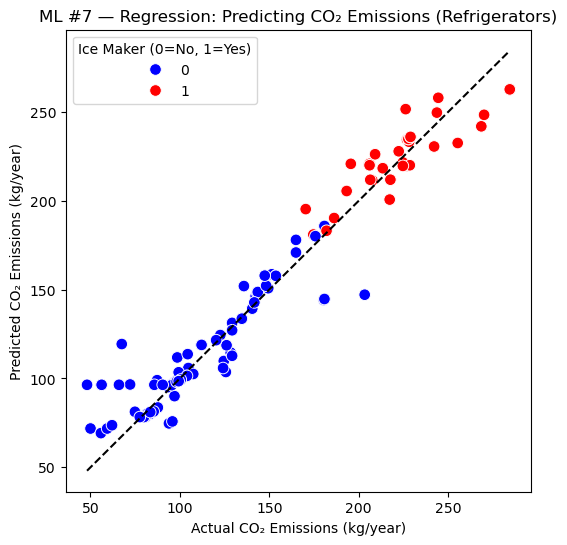

In [169]:
# ============================================
# ML #2 — Predict Carbon Dioxide Emissions 
# ============================================

df2 = dfRefrigeratorML.copy()

# -------------------------------------------------------
# 1. Select meaningful features (Your chosen 5 features)
# -------------------------------------------------------
features = [
    "Type",
    "Defrost Type",
    "Ice Maker",
    "Capacity (Total Volume) (ft3)",
    "Adjusted Volume (ft3)"
]

# Target = CO₂ emissions already computed earlier
target = "CO2_Emissions"   # kg CO₂ per year


# -------------------------------------------------------
# 2. Encode categorical features
# -------------------------------------------------------
cat_cols = ["Type", "Defrost Type"]

le = LabelEncoder()
for col in cat_cols:
    df2[col] = le.fit_transform(df2[col].astype(str))


# -------------------------------------------------------
# 3. Drop missing rows
# -------------------------------------------------------
df2 = df2.dropna(subset=features + [target])

X = df2[features]
y = df2[target]        # CO₂ in kg/year


# -------------------------------------------------------
# 4. Train/Test Split
# -------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


# -------------------------------------------------------
# 5. Baseline: Predict mean CO₂
# -------------------------------------------------------
baseline_pred = np.full_like(y_test, y_train.mean())
baseline_mse = mean_squared_error(y_test, baseline_pred)
baseline_r2 = r2_score(y_test, baseline_pred)


# -------------------------------------------------------
# 6. Linear Regression Model
# -------------------------------------------------------
reg = LinearRegression()
reg.fit(X_train, y_train)

y_pred_CO2 = reg.predict(X_test)


# -------------------------------------------------------
# 7. Evaluate
# -------------------------------------------------------
mse = mean_squared_error(y_test, y_pred_CO2)
r2 = r2_score(y_test, y_pred_CO2)

print("===== ML #7 — REGRESSION RESULTS (Refrigerators) =====")
print(f"Baseline MSE: {baseline_mse:.6f}")
print(f"Baseline R² Score: {baseline_r2:.6f}")
print(f"Model MSE: {mse:.6f}")
print(f"Model R² Score: {r2:.6f}\n")

print("Feature Coefficients:")
for name, coef in zip(features, reg.coef_):
    print(f"  {name}: {coef:.6f}")


# -------------------------------------------------------
# 8. Print the Regression Equation
# -------------------------------------------------------
intercept = reg.intercept_
coeffs = reg.coef_


# -------------------------------------------------------
# Convert CO₂ equation to metric tons (divide by 1000)
# -------------------------------------------------------
print("\n===== CO₂ Emissions Equation (metric tons/yr) =====")
equation_mt = f"CO2_mt = {intercept/1000:.6f}"

for name, coef in zip(features, coeffs):
    equation_mt += f" + ({coef/1000:.6f})*{name}"

print(equation_mt)


# -------------------------------------------------------
# 9. Plot Predicted vs Actual CO₂ Emissions
# -------------------------------------------------------
plt.figure(figsize=(6,6))
sns.scatterplot(
    x=y_test,
    y=y_pred_CO2,
    hue=X_test["Ice Maker"],   # color by Ice Maker
    palette={0: "blue", 1: "red"},
    s=70
)

# 45-degree perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "--", color="black"
)

plt.xlabel("Actual CO₂ Emissions (kg/year)")
plt.ylabel("Predicted CO₂ Emissions (kg/year)")
plt.title("ML #7 — Regression: Predicting CO₂ Emissions (Refrigerators)")
plt.legend(title="Ice Maker (0=No, 1=Yes)")
plt.show()


Let's go over the results for the Refrigerators ML. From the above values, it is clear that the baseline was HORRIBLE in predicting the output of the carbon emissions for refrigerators with a baseline score of 3621.86 and an R^2 of -0.012581. Our model performed significantly better that minimized this MSE to 212.417234 kg^2 which  which means my CO2 predictions are off by only 14.6 kg per year. Furthermore, our model has an R^2 of 0.94 which is really good as its positive and really close to 1. Therefore, predicting CO2 emissions for refirgerators using quantitative and qualitiatve features is a sucess and the model used here can successfully determine exactly how much carbon dioxide will be emitted with a set of these five main features!

## Reflection (Progress Report)

1. What is the most challenging part of the project that you’ve encountered so far?
The most challenging part of the project that we've encountered so far was actually obtaining and cleaning the data. There were so many appliances with empty or null values, and sometimes cleaning those columns would result in the deletion of some important rows which means that we had to sometimes keep null rows just for the sake of getting data. However, from our EDA, we saw that this does not necessarily add or delete noise in our graphs as they are not really important to the dataset as a whole. 

2. What are your initial insights? 
Energy use varies widely by appliance size and efficiency category. The visualizations indicate that the larger the appliance the more CO2 it will emit. Some features are more precise when predicting if an appliance will produce high or low CO2. This can be seen with the classification and also the regression line where we saw that in the classification, qualitiative features will not often predict whether an oven will produce high or low CO2 and give a general idea; on the other hand, quantitative analysis will be more precise. 

3. Are there any concrete results you can show at this point? If not, why not?
We have done substanital work for this progress report. First, we have cleaned the data and stored the cleaned data into different files. We then conducted an inital EDA to explore our data set. We then made hypothesis based on our EDA and also proved that our data was not biased. After that, we even did 2 ML analysis proving that some features can be good predictors of Carbon Dioxide. Overall, we think we did sufficient work for this progress report. 

4. Going forward, what are the current biggest problems you’re facing?
There is limited row count after cleaning which means that our ML test dataset and train dataset will be extremely small (not enough data for model to learn from). Also, the categorical features, as seen in ML analysis #1 are not good predictors. Finally, our CO2 calculations are derived from us using a formula we found from a trusted source. The dataset, unfortunately, did not have that number already...

5. Do you think you are on track with your project? If not, what parts do you need to dedicate more time to?
We are 100% on track with our project as we made substantial efforts already. We have exceeded the number of visualizations required and reached all of the other goals as well. 

6. Given your initial exploration of the data, is it worth proceeding with your project, why? If not, how will you move forward (method, data etc)?
It is 100% worth proceeding with our project as our exploration shows interesting data trends. Furthermore, when we were doing our regression line, we obtained an R^2 value of 0.60 which shows that our model and our data are appropriate enough to explore. 

## Next Steps (Progress Report)
1. Work on improving visualizations
2. Find a way to get/fill in empty rows and columns (imputing data)
3. Do ML analysis on the remaining 4 appliances...right now we just did ovens, but we have to finish the other 4 as well. 

## Conclusion (Final Report)

### Did we meet our goals for the next steps?
Yes and no...the problem with imputing our data with false data really skewed all of our visualizations and data sets, so we decided to just keep it as it is for the overall strength of the datasets (datasets that are smaller are better than larger datasets that have false values). regarding the ML analyses, we have successfully completed all our analases for all the appliances and made the models work correctly. 

### Overall Conclusion:
The goal of this project was to predict carbon dioxide emissions using quantitative and qualitative features. Throughout our entire project, we have been successfully able to classify which appliances will result in higher carbon dioxide emissions and lower carbon dioxide emissions and have also deduced formulas from the regression lines showing how much carbon dioxide will be emitted based on certain features for each application. Thus, consumers can have a better idea of how much carbon they are emitting and can be more greener with their choices!

## Sources

## https://www.energystar.gov/productfinder/advanced
Used this source as the sources of data that we used for our project

### https://www.epa.gov/energy/greenhouse-gas-equivalencies-calculator-calculations-and-references 
Used this source to obtain the formula to calculate kilowatts of energy to the Carbon Dioxide. 
